In [ ]:
"""
Processes geospatial raster data by clipping TIFF files to a polygon extracted
from a KMZ file. Loads rasters, extracts the clipping polygon, clips data,
filters invalid values, and saves the processed files.
"""

import os
import rioxarray as rxr
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
from pykml import parser
import zipfile
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import logging
from tqdm import tqdm

def setup_logging():
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s'
    )
    return logging.getLogger(__name__)

def extract_kmz_polygon(kmz_path):
    try:
        with zipfile.ZipFile(kmz_path, 'r') as kmz:
            kml_filename = next(name for name in kmz.namelist() if name.endswith('.kml'))
            with kmz.open(kml_filename) as kml_file:
                root = parser.fromstring(kml_file.read())

        namespace = {"kml": "http://www.opengis.net/kml/2.2"}
        coordinates = root.xpath(".//kml:coordinates/text()", namespaces=namespace)[0]
        polygon_coords = [tuple(map(float, coord.split(',')[:2]))
                         for coord in coordinates.split()]

        return Polygon(polygon_coords)
    except Exception as e:
        raise ValueError(f"Failed to extract polygon from KMZ: {e}")

def process_rasters(tiff_directory, kmz_path, output_directory, logger):
    # Setup directories
    tiff_directory = Path(tiff_directory)
    output_directory = Path(output_directory)
    output_directory.mkdir(parents=True, exist_ok=True)

    # Get polygon
    kmz_polygon = extract_kmz_polygon(kmz_path)
    polygon_gdf = gpd.GeoDataFrame(
        {'geometry': [kmz_polygon]},
        crs='EPSG:4326'
    )

    # Process rasters
    tiff_files = list(tiff_directory.glob('*.tiff'))
    for tiff_file in tqdm(tiff_files, desc="Processing rasters"):
        try:
            # Load and process raster
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=RuntimeWarning)
                raster = rxr.open_rasterio(tiff_file, masked=True).squeeze()

                # Project polygon
                projected_polygon = polygon_gdf.to_crs(raster.rio.crs)

                # Clip raster
                clipped = raster.rio.clip(
                    projected_polygon.geometry,
                    projected_polygon.crs,
                    drop=True
                )

                # Handle invalid values
                clipped = clipped.where(
                    (clipped < 1e38) & (clipped > -1e38),
                    np.nan
                )

                # Save output
                output_path = output_directory / f'clipped_{tiff_file.name}'
                clipped.rio.to_raster(
                    output_path,
                    dtype='float32',
                    nodata=np.nan
                )
                logger.info(f"Processed: {tiff_file.name}")

        except Exception as e:
            logger.error(f"Error processing {tiff_file.name}: {e}")
            continue
        finally:
            # Ensure resources are freed
            if 'raster' in locals():
                raster.close()
            if 'clipped' in locals():
                clipped.close()

def main():
    logger = setup_logging()

    try:
        process_rasters(
            tiff_directory='dataset/',
            kmz_path='ICA_polygon_C2VSimregions.kmz',
            output_directory='clipped_rasters2/',
            logger=logger
        )
    except Exception as e:
        logger.error(f"Critical error: {e}")

if __name__ == "__main__":
    main()

Processing rasters:   0%|                               | 0/109 [00:00<?, ?it/s]2024-11-30 14:27:02,413 - WARNING - CPLE_AppDefined in PROJ: internal_proj_create_from_database: /Users/rohit/miniforge3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/rohit/miniforge3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/rohit/miniforge3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.
2024-11-30 14:27:02,604 - INFO - GDAL signalled an error: err_no=1, msg='PROJ: internal_proj_create_from_name: /Users/rohit/miniforge3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ 

In [ ]:
"""
Creates a multi-band GeoTIFF by stacking clipped raster files sorted by date.
Extracts dates from filenames, processes raster bands, filters invalid values,
and assigns metadata for each time step.
"""

import os
import rioxarray as rxr
import numpy as np
from datetime import datetime
import rasterio
from rasterio.transform import from_bounds
from tqdm import tqdm

clipped_tiff_directory = 'clipped_rasters2/'
output_tiff_path = 'multiband_clipped_rasters_with_dates2.tiff'

def extract_second_date_from_filename(filename):
    try:
        date_str = filename.split('_')[2].split('.')[0].strip()
        return datetime.strptime(date_str, '%Y%m%d').strftime('%Y-%m-%d')
    except ValueError as e:
        return None

tiff_files = [f for f in os.listdir(clipped_tiff_directory) if f.endswith('.tiff')]
tiff_files_sorted = sorted([f for f in tiff_files if extract_second_date_from_filename(f)],
                          key=extract_second_date_from_filename)
dates = [extract_second_date_from_filename(f) for f in tiff_files_sorted]

with rasterio.open(os.path.join(clipped_tiff_directory, tiff_files_sorted[0])) as src:
    profile = src.profile.copy()
    profile.update({
        'count': len(tiff_files_sorted),
        'nodata': np.nan,
        'dtype': 'float32'
    })

with rasterio.open(output_tiff_path, 'w', **profile) as dst:
    for idx, (tiff_file, date) in enumerate(zip(tiff_files_sorted, dates), 1):
        with rasterio.open(os.path.join(clipped_tiff_directory, tiff_file)) as src:
            data = src.read(1)
            data = np.where(data > 1e38, np.nan, data)
            dst.write(data, idx)
            dst.set_band_description(idx, f"Date: {date}")

print(f"Multi-band GeoTIFF saved to {output_tiff_path}")

# Verify minimum values
with rasterio.open(output_tiff_path) as src:
    data = src.read()
    for i, date in enumerate(dates):
        min_value = np.nanmin(data[i])
        min_loc = np.where(data[i] == min_value)
        y, x = min_loc[0][0], min_loc[1][0]
        transform = src.transform
        lon = transform[0] * x + transform[2]
        lat = transform[4] * y + transform[5]
        print(f"Date: {date}, Subsidence = {min_value} feet")

2024-11-30 14:28:25,436 - INFO - GDAL signalled an error: err_no=1, msg='PROJ: internal_proj_create_from_name: /Users/rohit/miniforge3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.'


Multi-band GeoTIFF saved to multiband_clipped_rasters_with_dates2.tiff
Date: 2015-07-01, Subsidence = -0.09089960902929306 feet
Date: 2015-08-01, Subsidence = -0.253806471824646 feet
Date: 2015-09-01, Subsidence = -0.40965864062309265 feet
Date: 2015-10-01, Subsidence = -0.5472197532653809 feet
Date: 2015-11-01, Subsidence = -0.6493756771087646 feet
Date: 2015-12-01, Subsidence = -0.7523092031478882 feet
Date: 2016-01-01, Subsidence = -0.8337901830673218 feet
Date: 2016-02-01, Subsidence = -0.9164136052131653 feet
Date: 2016-03-01, Subsidence = -0.9734733700752258 feet
Date: 2016-04-01, Subsidence = -1.0652321577072144 feet
Date: 2016-05-01, Subsidence = -1.1725496053695679 feet
Date: 2016-06-01, Subsidence = -1.323608160018921 feet
Date: 2016-07-01, Subsidence = -1.474560260772705 feet
Date: 2016-08-01, Subsidence = -1.6469056606292725 feet
Date: 2016-09-01, Subsidence = -1.8189960718154907 feet
Date: 2016-10-01, Subsidence = -1.9491387605667114 feet
Date: 2016-11-01, Subsidence = -2.

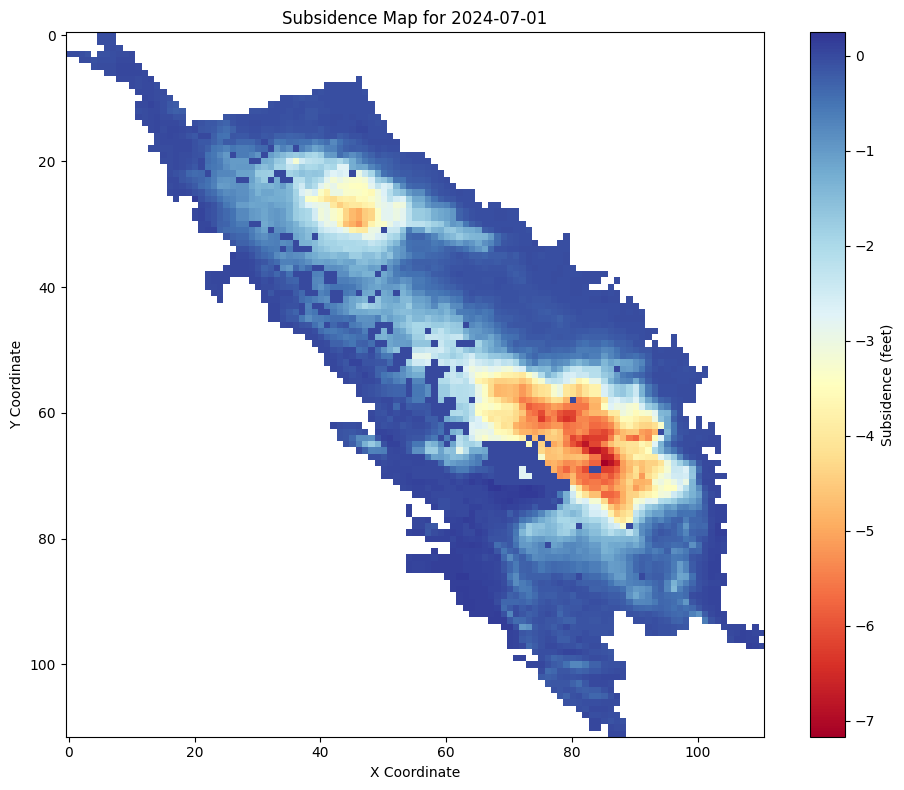


Date: 2024-07-01
Min: -7.17 ft
Max: 0.25 ft
Mean: -0.98 ft


In [ ]:
"""
Loads and visualizes the latest subsidence data from a multi-band GeoTIFF.
Extracts date metadata, plots the most recent subsidence map, and prints
basic statistics including min, max, and mean values.
"""

import rasterio
import matplotlib.pyplot as plt
import numpy as np

tiff_path = 'multiband_clipped_rasters_with_dates2.tiff'

# Open the GeoTIFF file
with rasterio.open(tiff_path) as src:
    # Get dates from band descriptions
    band_descriptions = [src.descriptions[i] for i in range(src.count)]
    dates = [desc.split(": ")[1] if desc else "Unknown Date" for desc in band_descriptions]

    # Get last band data
    last_band = src.count
    data = src.read(last_band)
    transform = src.transform
    selected_date = dates[-1]

    # Create plot
    plt.figure(figsize=(10, 8))

    # Plot the data
    plt.imshow(data, cmap='RdYlBu')
    plt.colorbar(label='Subsidence (feet)')

    plt.title(f"Subsidence Map for {selected_date}")
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')

    plt.grid(False)
    plt.tight_layout()
    plt.show()

    # Print basic statistics
    print(f"\nDate: {selected_date}")
    print(f"Min: {np.nanmin(data):.2f} ft")
    print(f"Max: {np.nanmax(data):.2f} ft")
    print(f"Mean: {np.nanmean(data):.2f} ft")

2024-11-30 14:29:18,272 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-11-30 14:29:18,277 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


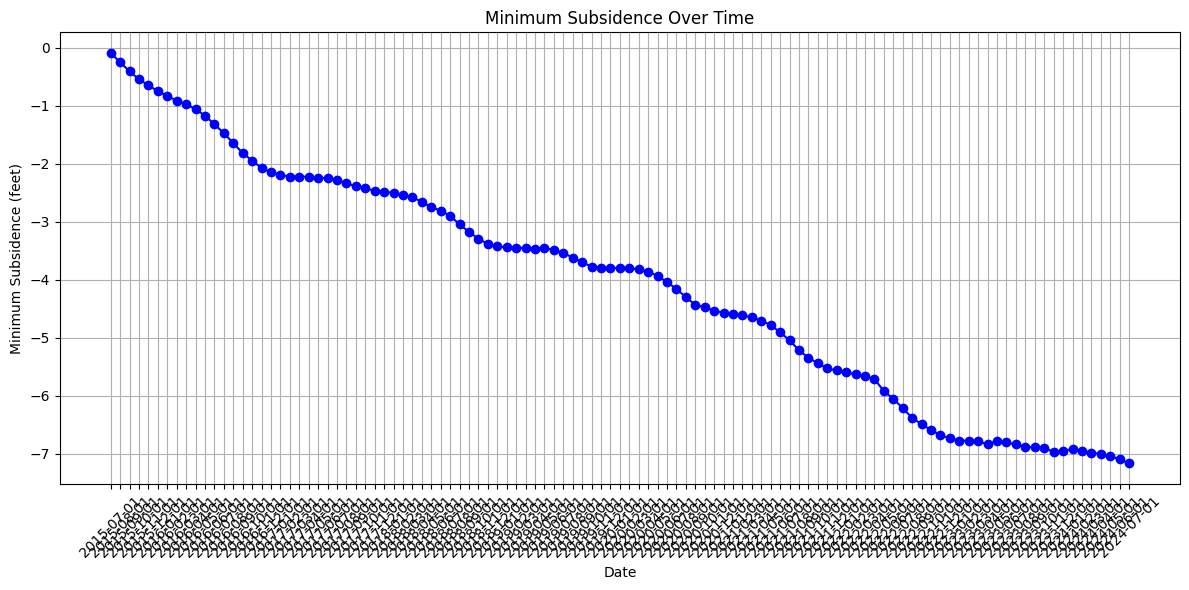

In [ ]:
"""
Plots the minimum subsidence values over time from a multi-band GeoTIFF.
Extracts date metadata, computes minimum subsidence per time step, and
visualizes the trend using a time series plot.
"""

import matplotlib.pyplot as plt

with rasterio.open(output_tiff_path) as src:
    data = src.read()
    min_values = [np.nanmin(band) for band in data]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(dates, min_values, 'b-o')
    ax.set_xlabel('Date')
    ax.set_ylabel('Minimum Subsidence (feet)')
    ax.set_title('Minimum Subsidence Over Time')
    ax.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

In [ ]:
"""
Extracts and exports subsidence data from a multi-band GeoTIFF. Reads raster bands,
retrieves geographic coordinates, filters data based on latitude, and saves the
results as a CSV file with timestamps and subsidence values.
"""

import rasterio
import pandas as pd
import numpy as np
from rasterio.transform import xy
from datetime import datetime
from tqdm import tqdm

stacked_tiff_path = 'multiband_clipped_rasters_with_dates2.tiff'
data_list = []

with rasterio.open(stacked_tiff_path) as src:
    transform = src.transform
    num_bands = src.count

    for band_idx in tqdm(range(1, num_bands + 1), desc="Processing bands"):
        band_data = src.read(band_idx)
        band_description = src.descriptions[band_idx - 1]
        date_str = band_description.split('Date: ')[1]

        valid_pixels = np.where(~np.isnan(band_data))
        for row, col in zip(*valid_pixels):
            x, y = xy(transform, row, col)

            # Only include data where latitude (y) is less than or equal to 36.5
            if y <= 36.5:
                subsidence_value = band_data[row, col]
                data_list.append({
                    'Date': date_str,
                    'X': round(x, 6),
                    'Y': round(y, 6),
                    'Subsidence': float(subsidence_value)
                })

df = pd.DataFrame(data_list)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'X', 'Y'])
df.to_csv('subsidence_data_truncated.csv', index=False, float_format='%.6f')

print("\nDataset Summary:")
print(f"Total records: {len(df)}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Subsidence range: {df['Subsidence'].min():.2f} to {df['Subsidence'].max():.2f}")

Processing bands: 100%|███████████████████████| 109/109 [00:10<00:00, 10.53it/s]



Dataset Summary:
Total records: 267944
Date range: 2015-07-01 00:00:00 to 2024-07-01 00:00:00
Subsidence range: -7.17 to 0.33


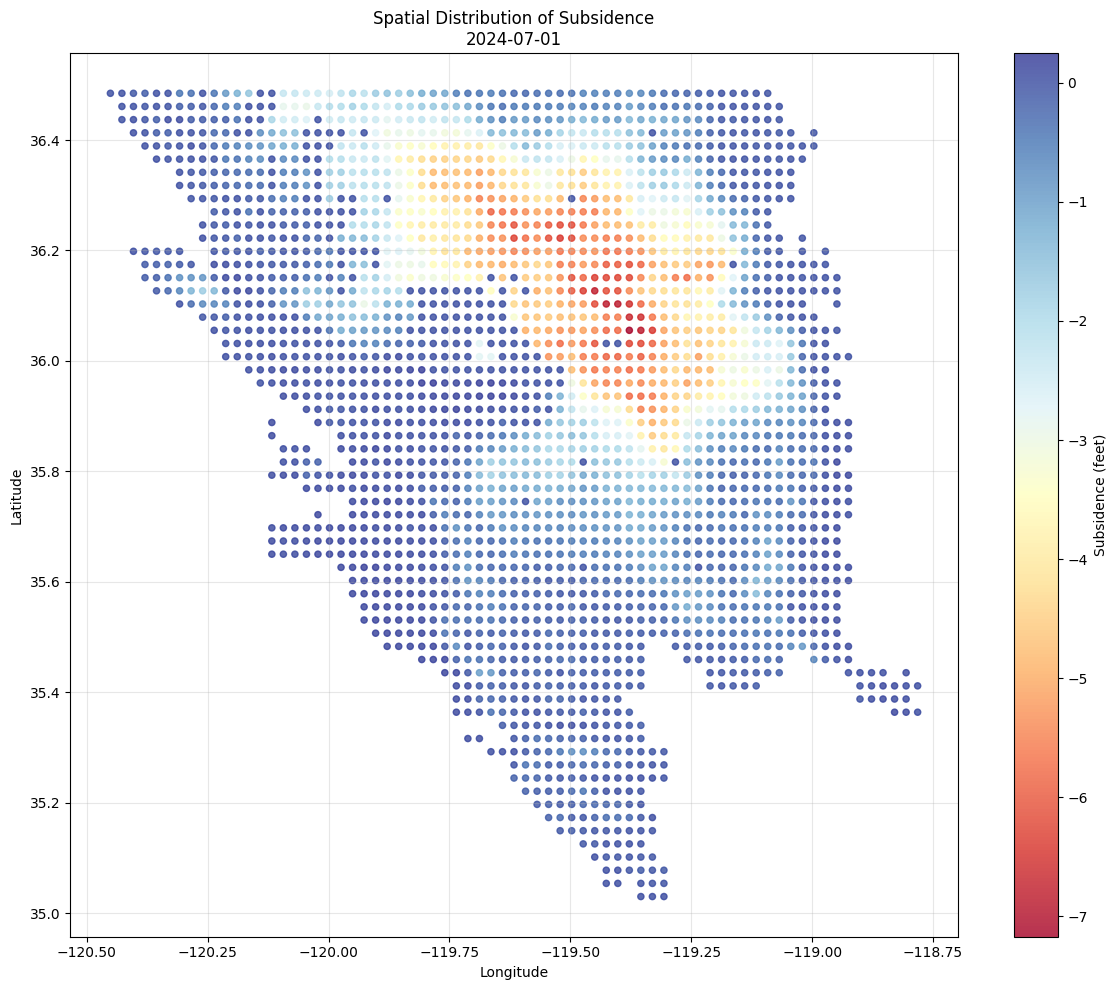

Plotting data for date: 2024-07-01
Number of points plotted: 2458


In [ ]:
"""
Visualizes the spatial distribution of subsidence for the most recent date.
Reads subsidence data from a CSV, filters for the latest date, and creates a
scatter plot with color mapping to represent subsidence values.
"""

import matplotlib.pyplot as plt
import pandas as pd

# Read the truncated CSV
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Get the last date's data
last_date = df['Date'].max()
last_date_data = df[df['Date'] == last_date]

# Create the spatial plot
plt.figure(figsize=(12, 10))
scatter = plt.scatter(last_date_data['X'],
                     last_date_data['Y'],
                     c=last_date_data['Subsidence'],
                     cmap='RdYlBu',
                     s=20,  # Increased point size
                     alpha=0.8)  # Added some transparency

plt.colorbar(scatter, label='Subsidence (feet)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Spatial Distribution of Subsidence\n{last_date.strftime("%Y-%m-%d")}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Plotting data for date: {last_date.strftime('%Y-%m-%d')}")
print(f"Number of points plotted: {len(last_date_data)}")

/Users/rohit/geo_project_env/lib/python3.9/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(



Data Summary:
Number of time points: 109
Number of spatial points: 2460


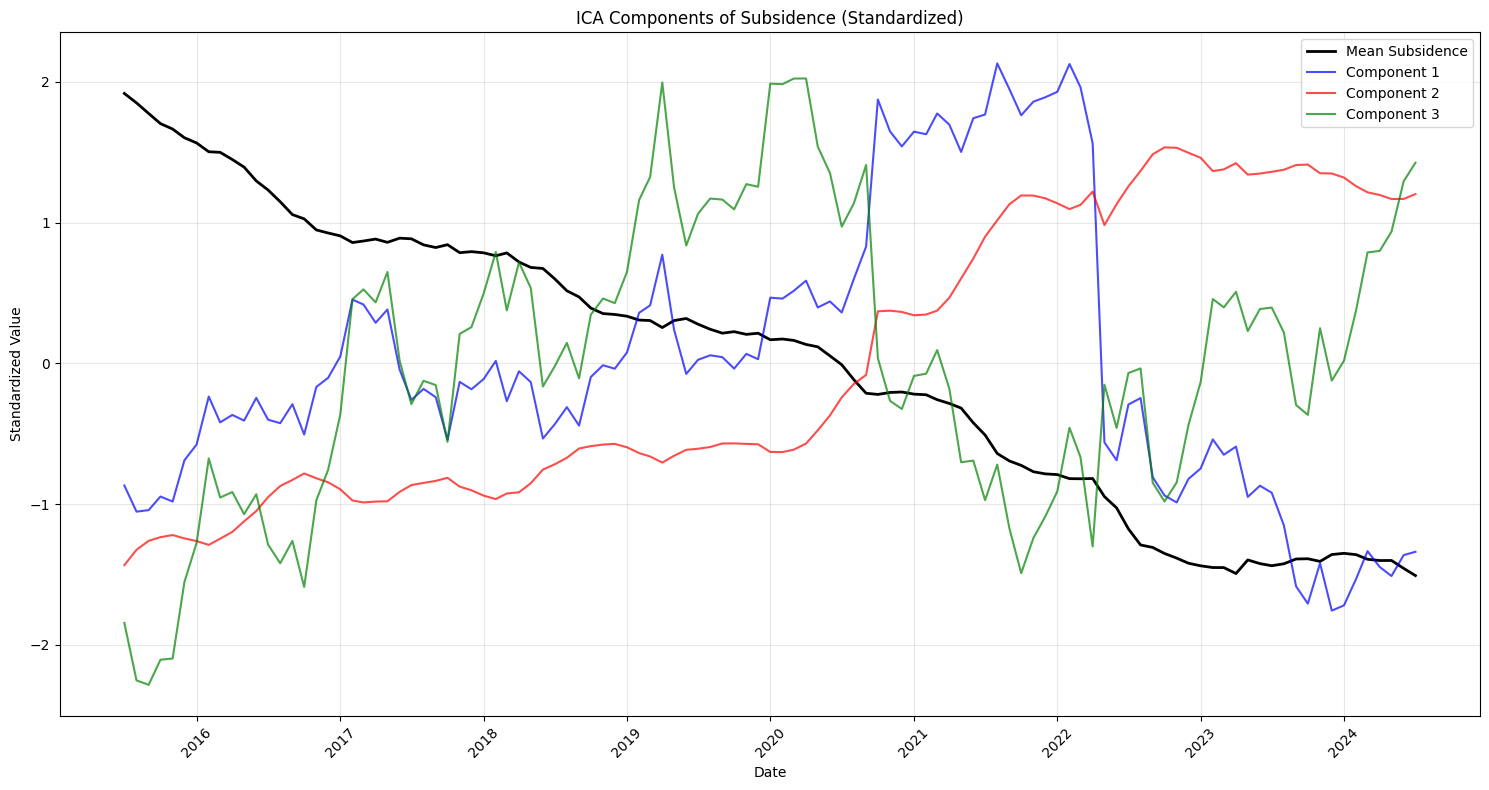

In [ ]:
"""
Performs Independent Component Analysis (ICA) on subsidence time-series data.
Loads, preprocesses, and standardizes the dataset, extracts three ICA components,
and visualizes them alongside the mean subsidence trend.
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt

def plot_scaled_timeseries(filepath):
    # Load and process data
    df = pd.read_csv(filepath)
    df['Date'] = pd.to_datetime(df['Date'])

    # Create pivot table for time series analysis
    pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')

    # Handle missing values
    pivot_df = pivot_df.interpolate(method='linear', axis=0)
    pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
    pivot_df = pivot_df.fillna(pivot_df.mean())

    # Calculate mean subsidence
    mean_subsidence = pivot_df.mean(axis=1)

    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(pivot_df)

    # Scale mean subsidence
    mean_scaler = StandardScaler()
    mean_scaled = mean_scaler.fit_transform(mean_subsidence.values.reshape(-1, 1)).flatten()

    # Apply ICA
    ica = FastICA(n_components=3, random_state=42, max_iter=1000)
    components = ica.fit_transform(X_scaled)

    # Create plot
    plt.figure(figsize=(15, 8))

    # Plot mean subsidence
    plt.plot(pivot_df.index, mean_scaled, 'k-',
            label='Mean Subsidence', linewidth=2)

    # Plot ICA components
    colors = ['b', 'r', 'g']
    for i in range(3):
        plt.plot(pivot_df.index, components[:, i],
                color=colors[i],
                label=f'Component {i+1}',
                alpha=0.7)

    # Customize plot
    plt.title('ICA Components of Subsidence (Standardized)')
    plt.xlabel('Date')
    plt.ylabel('Standardized Value')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Print summary statistics
    print("\nData Summary:")
    print(f"Number of time points: {pivot_df.shape[0]}")
    print(f"Number of spatial points: {pivot_df.shape[1]}")

    plt.show()

# Apply to your new truncated dataset
plot_scaled_timeseries('subsidence_data_truncated.csv')

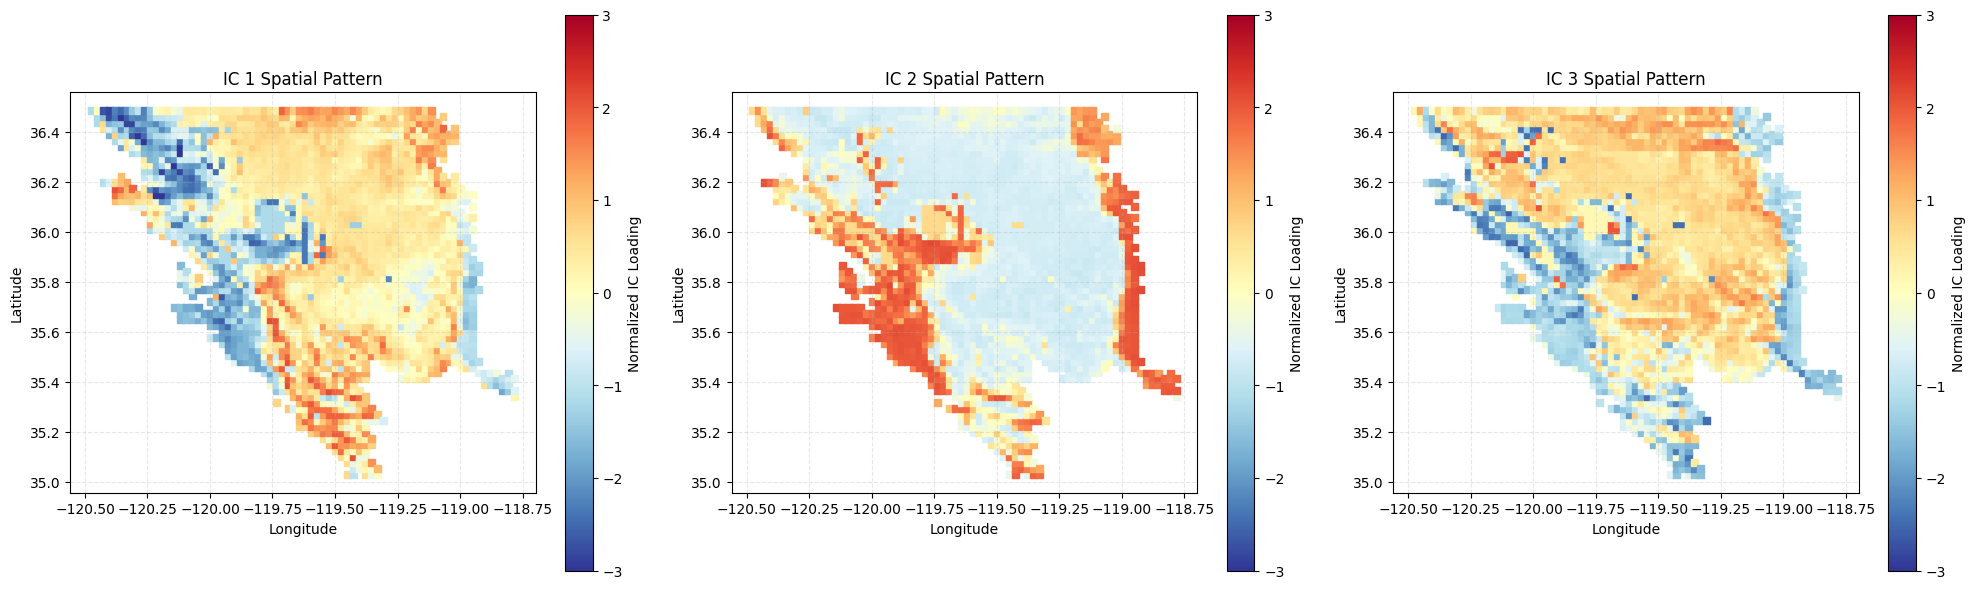

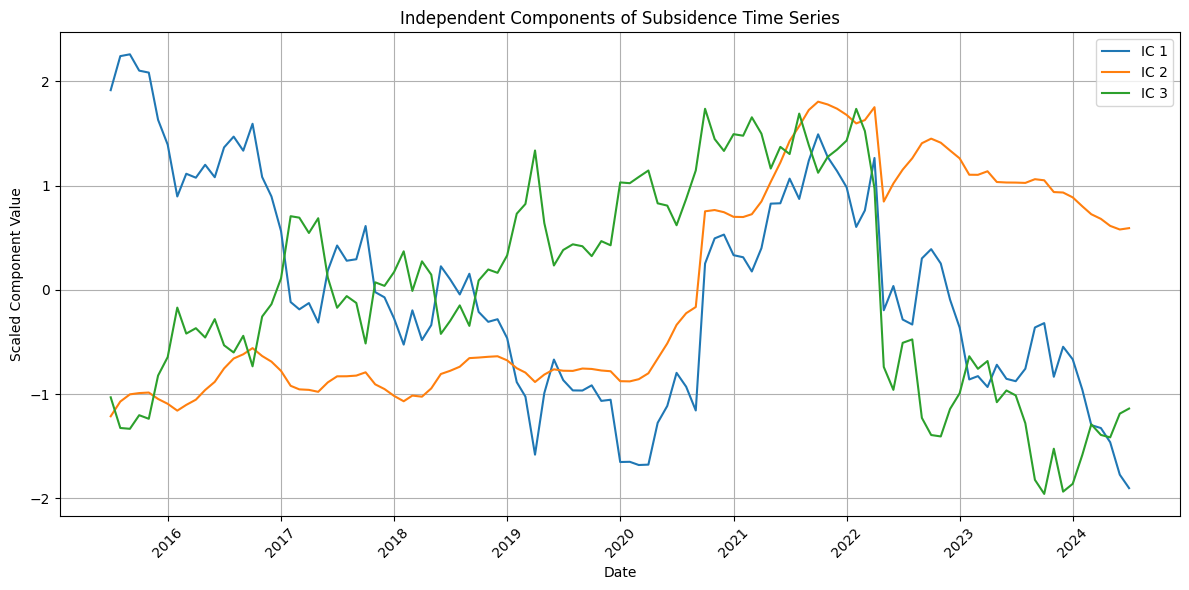

In [ ]:
"""
Performs Independent Component Analysis (ICA) on subsidence data to identify
spatiotemporal patterns. Constructs a pivot table, interpolates missing values,
standardizes data, and extracts three independent components.

Visualizes spatial IC loadings using scatter plots and plots temporal evolution
of ICs over time.
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Create pivot table
pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')
pivot_df = pivot_df.interpolate(method='linear', axis=0)
pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
pivot_df = pivot_df.fillna(pivot_df.mean())

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot_df)

# Get coordinates
coords = np.array([[x, y] for x, y in zip(
    pivot_df.columns.get_level_values(0),
    pivot_df.columns.get_level_values(1)
)])

# Run ICA on scaled data
ica = FastICA(n_components=3, random_state=42)
components = ica.fit_transform(X_scaled)

# Normalize mixing coefficients
normalized_mixing = (ica.mixing_ - ica.mixing_.mean(axis=0)) / ica.mixing_.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i in range(3):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_mixing[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'IC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')a
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized IC Loading')
plt.tight_layout()
plt.show()

# Plot scaled time series
fig, ax = plt.subplots(figsize=(12, 6))
dates = pivot_df.index

# Scale components for visualization
components_scaled = components

for i in range(3):
    ax.plot(dates, components_scaled[:, i], label=f'IC {i+1}')
ax.set_xlabel('Date')
ax.set_ylabel('Scaled Component Value')
ax.set_title('Independent Components of Subsidence Time Series')
ax.grid(True)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



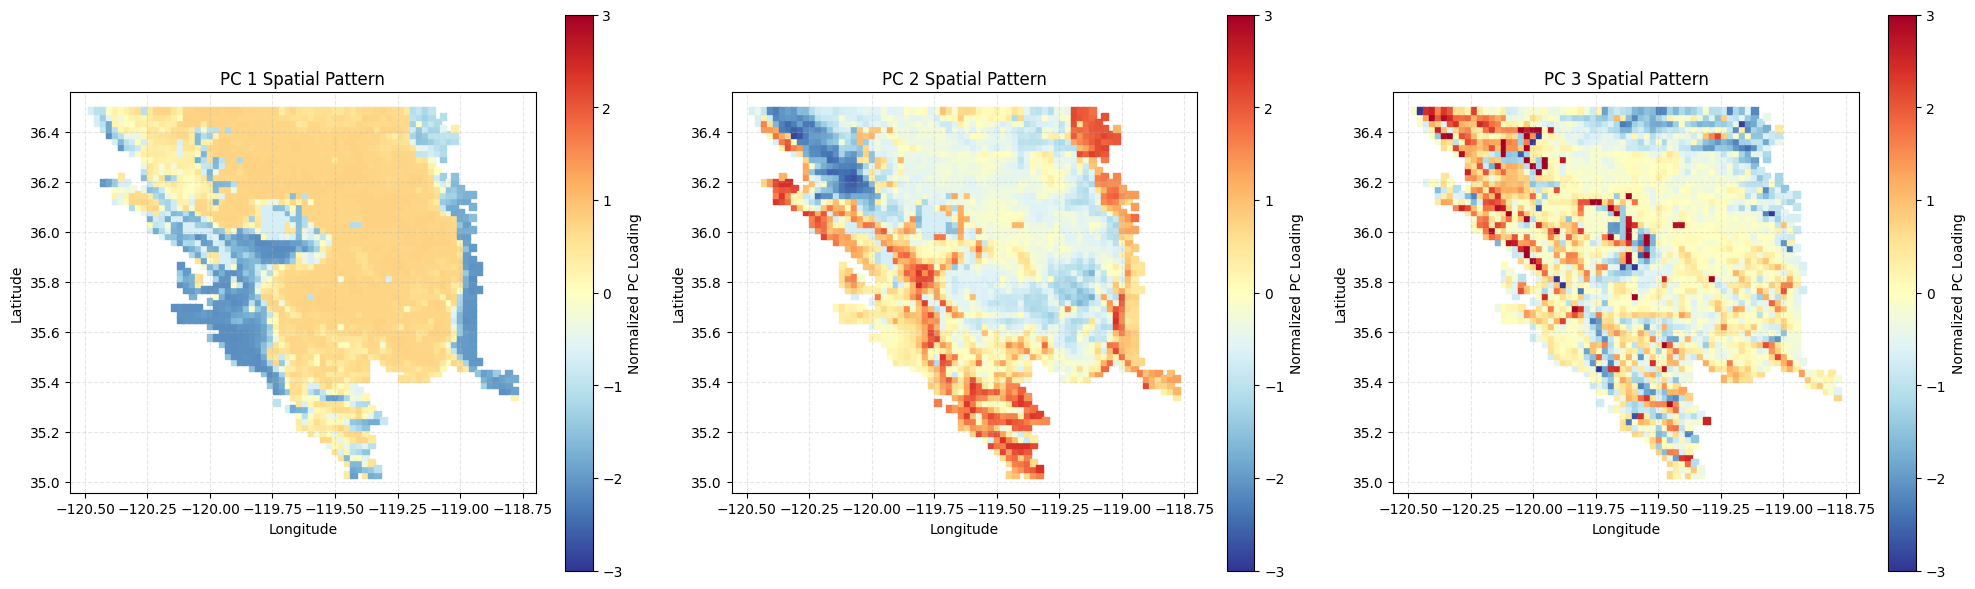

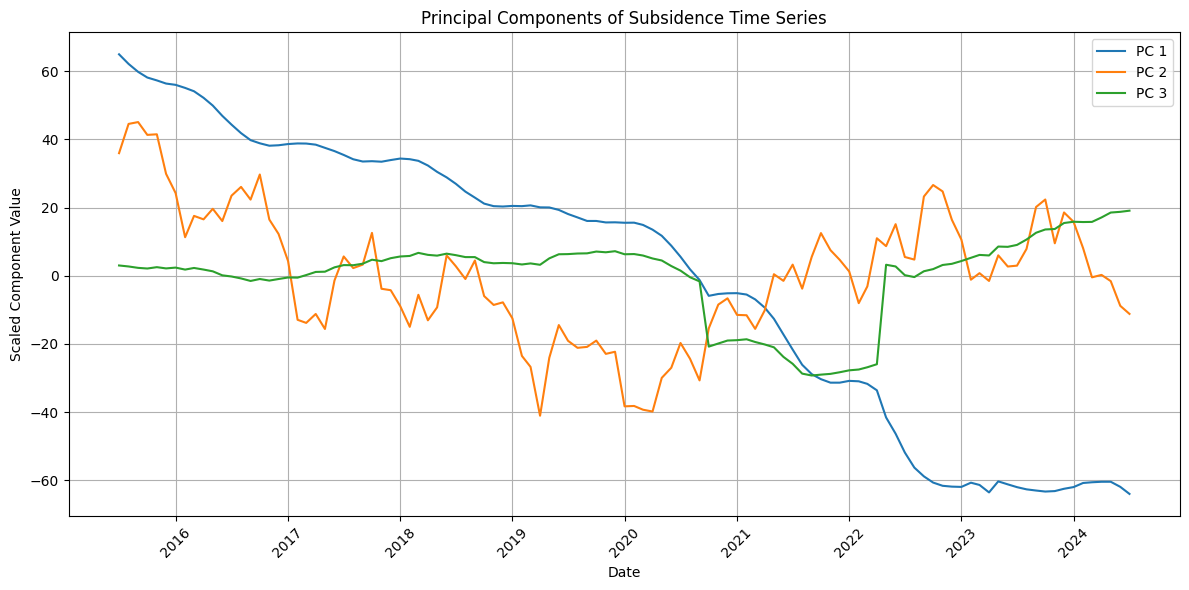

In [ ]:
"""
Performs Principal Component Analysis (PCA) on subsidence data to identify
dominant patterns in spatiotemporal variations. Constructs a pivot table,
interpolates missing values, standardizes data, and extracts three principal
components.

Visualizes spatial PCA loadings using scatter plots and plots the temporal
evolution of principal components over time.
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Create pivot table
pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')
pivot_df = pivot_df.interpolate(method='linear', axis=0)
pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
pivot_df = pivot_df.fillna(pivot_df.mean())

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot_df)

# Get coordinates
coords = np.array([[x, y] for x, y in zip(
    pivot_df.columns.get_level_values(0),
    pivot_df.columns.get_level_values(1)
)])

# Run PCA on scaled data
pca = PCA(n_components=3, random_state=42)
components = pca.fit_transform(X_scaled)

# Normalize loading patterns (eigenvectors)
normalized_loading = (pca.components_.T - pca.components_.T.mean(axis=0)) / pca.components_.T.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i in range(3):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_loading[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'PC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized PC Loading')
plt.tight_layout()
plt.show()

# Plot scaled time series
fig, ax = plt.subplots(figsize=(12, 6))
dates = pivot_df.index
components_scaled = components

for i in range(3):
    ax.plot(dates, components_scaled[:, i], label=f'PC {i+1}')
ax.set_xlabel('Date')
ax.set_ylabel('Scaled Component Value')
ax.set_title('Principal Components of Subsidence Time Series')
ax.grid(True)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2024-11-30 14:57:02,661 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-11-30 14:57:02,664 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Date: 2019-01-01, Subsidence = -0.2044796347618103 feet
Date: 2019-02-01, Subsidence = -0.22500741481781006 feet
Date: 2019-03-01, Subsidence = -0.2232685536146164 feet
Date: 2019-04-01, Subsidence = -0.23783011734485626 feet
Date: 2019-05-01, Subsidence = -0.21145646274089813 feet
Date: 2019-06-01, Subsidence = -0.19334831833839417 feet
Date: 2019-07-01, Subsidence = -0.202775239944458 feet
Date: 2019-08-01, Subsidence = -0.21184661984443665 feet
Date: 2019-09-01, Subsidence = -0.22402067482471466 feet
Date: 2019-10-01, Subsidence = -0.23039522767066956 feet
Date: 2019-11-01, Subsidence = -0.24260106682777405 feet
Date: 2019-12-01, Subsidence = -0.2460654228925705 feet
Date: 2020-01-01, Subsidence = -0.275011271238327 feet
Date: 2020-02-01, Subsidence = -0.27629196643829346 feet
Date: 2020-03-01, Subsidence = -0.2779937982559204 feet
Date: 2020-04-01, Subsidence = -0.28122687339782715 feet
Date: 2020-05-01, Subsidence = -0.27027302980422974 feet
Date: 2020-06-01, Subsidence = -0.26768

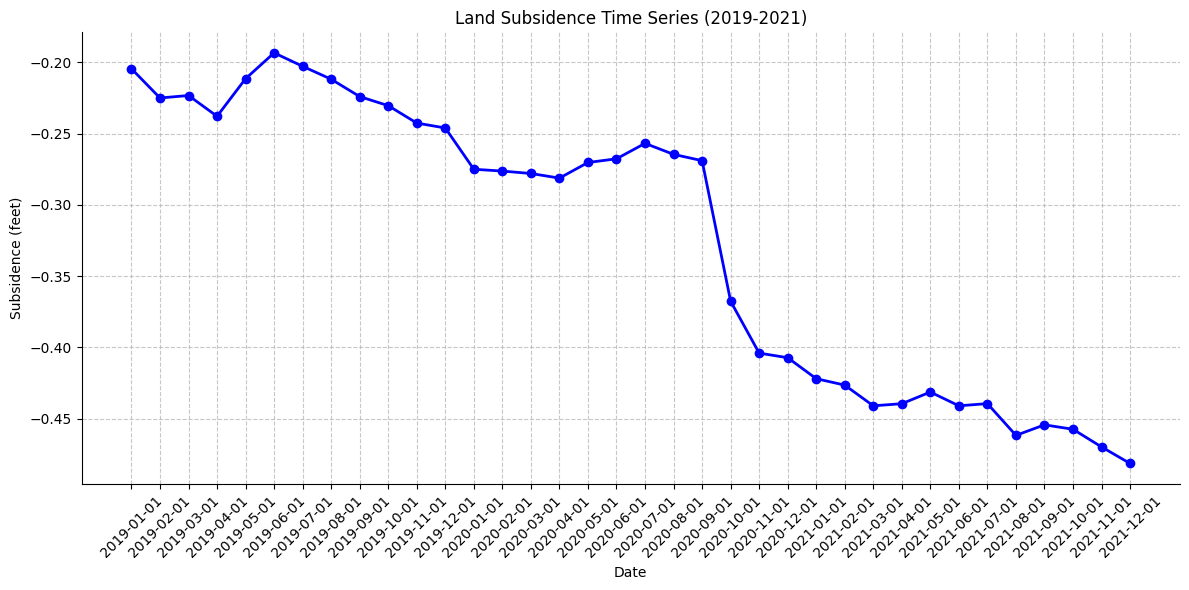

In [ ]:
"""
Extracts and visualizes the subsidence time series for a specific geographic
location from a multi-band GeoTIFF. Retrieves subsidence values for the selected
longitude and latitude, filters data for 2019-2021, and plots the time series.
"""

from rasterio.transform import rowcol
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

def plot_pixel_subsidence_multiband2(output_tiff_path, target_lon, target_lat):
    with rasterio.open(output_tiff_path) as src:
        band_descriptions = [src.descriptions[i] for i in range(src.count)]
        dates = [desc.split(": ")[1] for desc in band_descriptions]

        data = src.read()
        row, col = rowcol(src.transform, target_lon, target_lat)

        values = []
        valid_dates = []

        for i, date in enumerate(dates):
            date_obj = datetime.strptime(date, '%Y-%m-%d')
            if date_obj.year >= 2019 and date_obj.year <= 2021:
                value = data[i, row, col]
                if not np.isnan(value):
                    values.append(value)
                    valid_dates.append(date)
                    print(f"Date: {date}, Subsidence = {value} feet")

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(valid_dates, values, 'b-o', linewidth=2, markersize=6)

        ax.set_xlabel('Date')
        ax.set_ylabel('Subsidence (feet)')
        ax.set_title('Land Subsidence Time Series (2019-2021)')

        ax.grid(True, linestyle='--', alpha=0.7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.xticks(rotation=45)
        plt.tight_layout()

        return fig

target_lon, target_lat = -120.117362, 36.842423
output_tiff_path = 'multiband_clipped_rasters_with_dates2.tiff'

fig = plot_pixel_subsidence_multiband2(output_tiff_path, target_lon, target_lat)
plt.show()

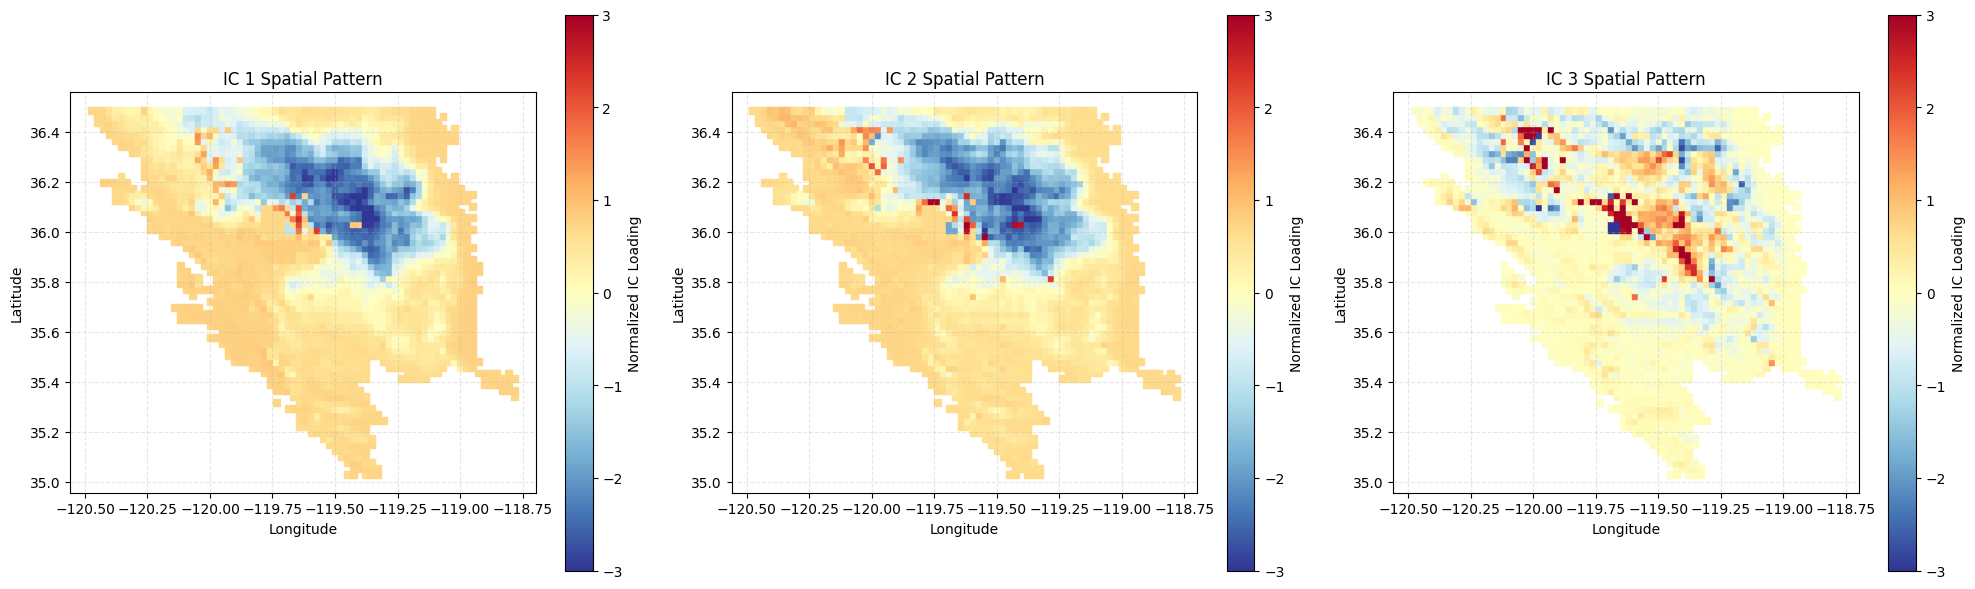

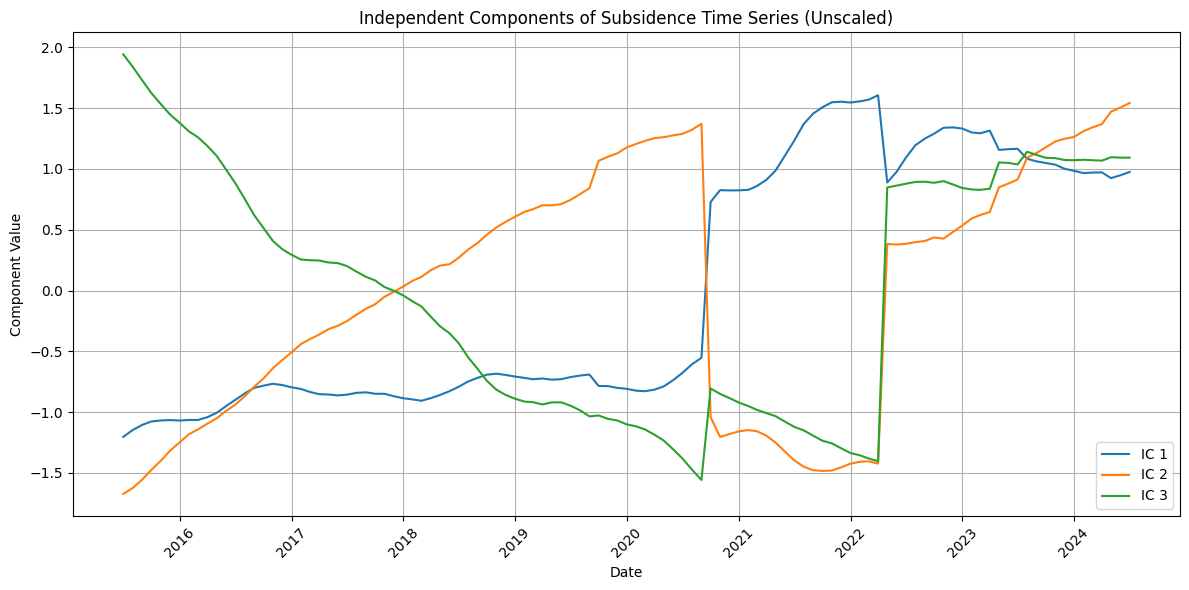

In [ ]:

"""
Applies Independent Component Analysis (ICA) to subsidence data to extract independent spatial and temporal patterns.
1. Loads and preprocesses data, handling missing values.
2. Runs ICA on unscaled data to separate independent subsidence signals.
3. Visualizes extracted spatial patterns and time series components.
"""

import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Create pivot table
pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')
pivot_df = pivot_df.interpolate(method='linear', axis=0)
pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
pivot_df = pivot_df.fillna(pivot_df.mean())

# Get coordinates
coords = np.array([[x, y] for x, y in zip(
    pivot_df.columns.get_level_values(0),
    pivot_df.columns.get_level_values(1)
)])

# Run ICA on unscaled data
ica = FastICA(n_components=3, random_state=42)
components = ica.fit_transform(pivot_df)

# Normalize mixing coefficients
normalized_mixing = (ica.mixing_ - ica.mixing_.mean(axis=0)) / ica.mixing_.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i in range(3):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_mixing[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'IC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized IC Loading')
plt.tight_layout()
plt.show()

# Plot raw time series
fig, ax = plt.subplots(figsize=(12, 6))
dates = pivot_df.index

# Plot components without scaling
for i in range(3):
    ax.plot(dates, components[:, i], label=f'IC {i+1}')
ax.set_xlabel('Date')
ax.set_ylabel('Component Value')
ax.set_title('Independent Components of Subsidence Time Series (Unscaled)')
ax.grid(True)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


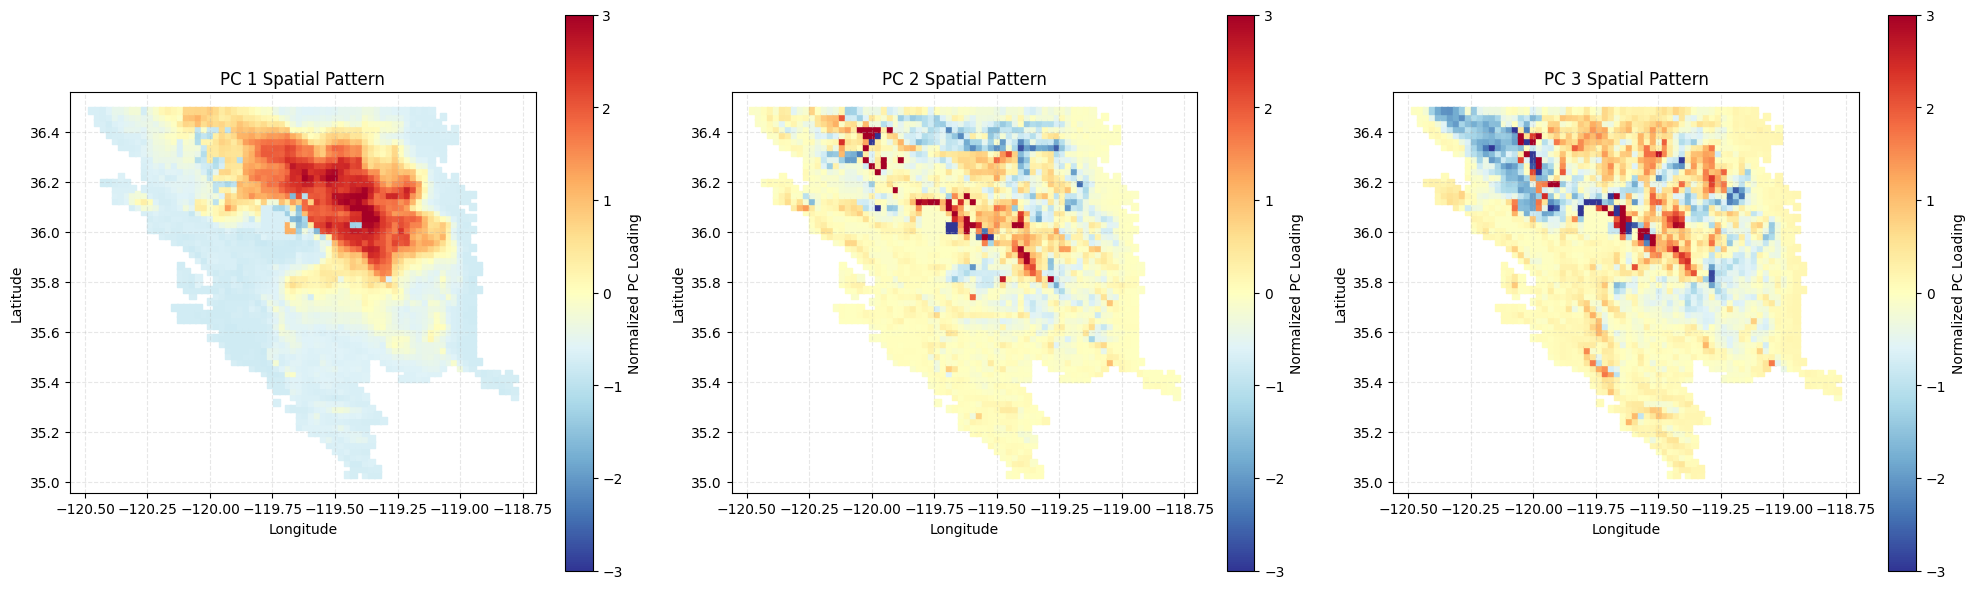

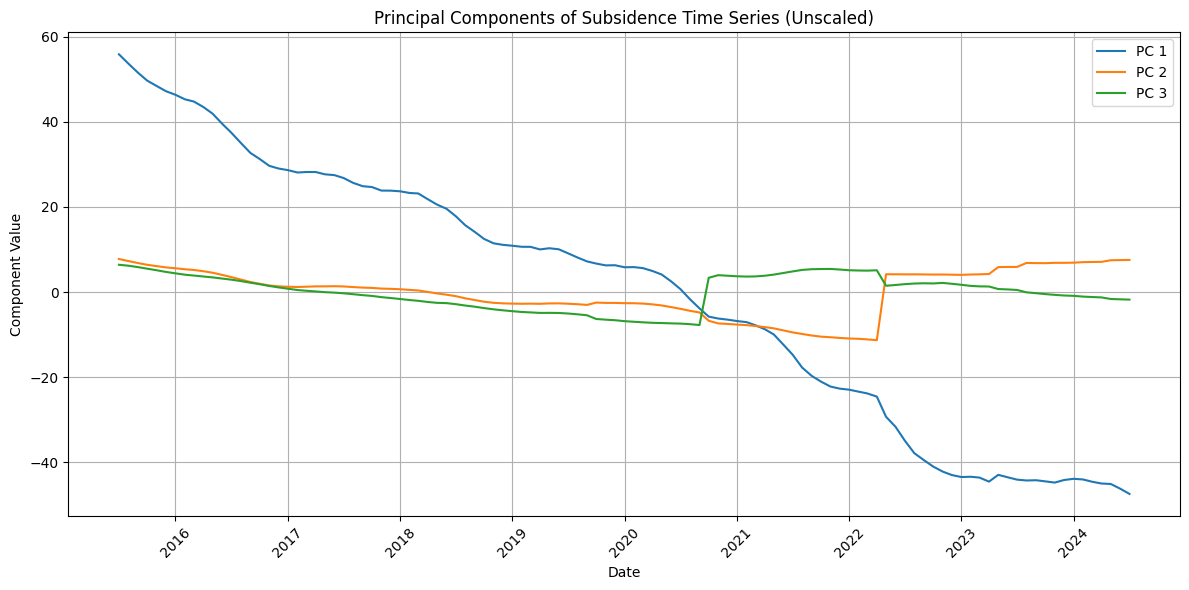

In [ ]:
"""
Applies Principal Component Analysis (PCA) to subsidence data to identify dominant spatial and temporal patterns.
1. Loads and preprocesses data, handling missing values.
2. Runs PCA on unscaled data to extract principal components.
3. Visualizes spatial patterns and temporal trends of extracted components.
"""

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Create pivot table
pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')
pivot_df = pivot_df.interpolate(method='linear', axis=0)
pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
pivot_df = pivot_df.fillna(pivot_df.mean())

# Get coordinates
coords = np.array([[x, y] for x, y in zip(
    pivot_df.columns.get_level_values(0),
    pivot_df.columns.get_level_values(1)
)])

# Run PCA on unscaled data
pca = PCA(n_components=3, random_state=42)
components = pca.fit_transform(pivot_df)

# Normalize loading patterns (eigenvectors)
normalized_loading = (pca.components_.T - pca.components_.T.mean(axis=0)) / pca.components_.T.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i in range(3):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_loading[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'PC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized PC Loading')
plt.tight_layout()
plt.show()

# Plot raw time series
fig, ax = plt.subplots(figsize=(12, 6))
dates = pivot_df.index
components_scaled = components

for i in range(3):
    ax.plot(dates, components_scaled[:, i], label=f'PC {i+1}')
ax.set_xlabel('Date')
ax.set_ylabel('Component Value')
ax.set_title('Principal Components of Subsidence Time Series (Unscaled)')
ax.grid(True)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


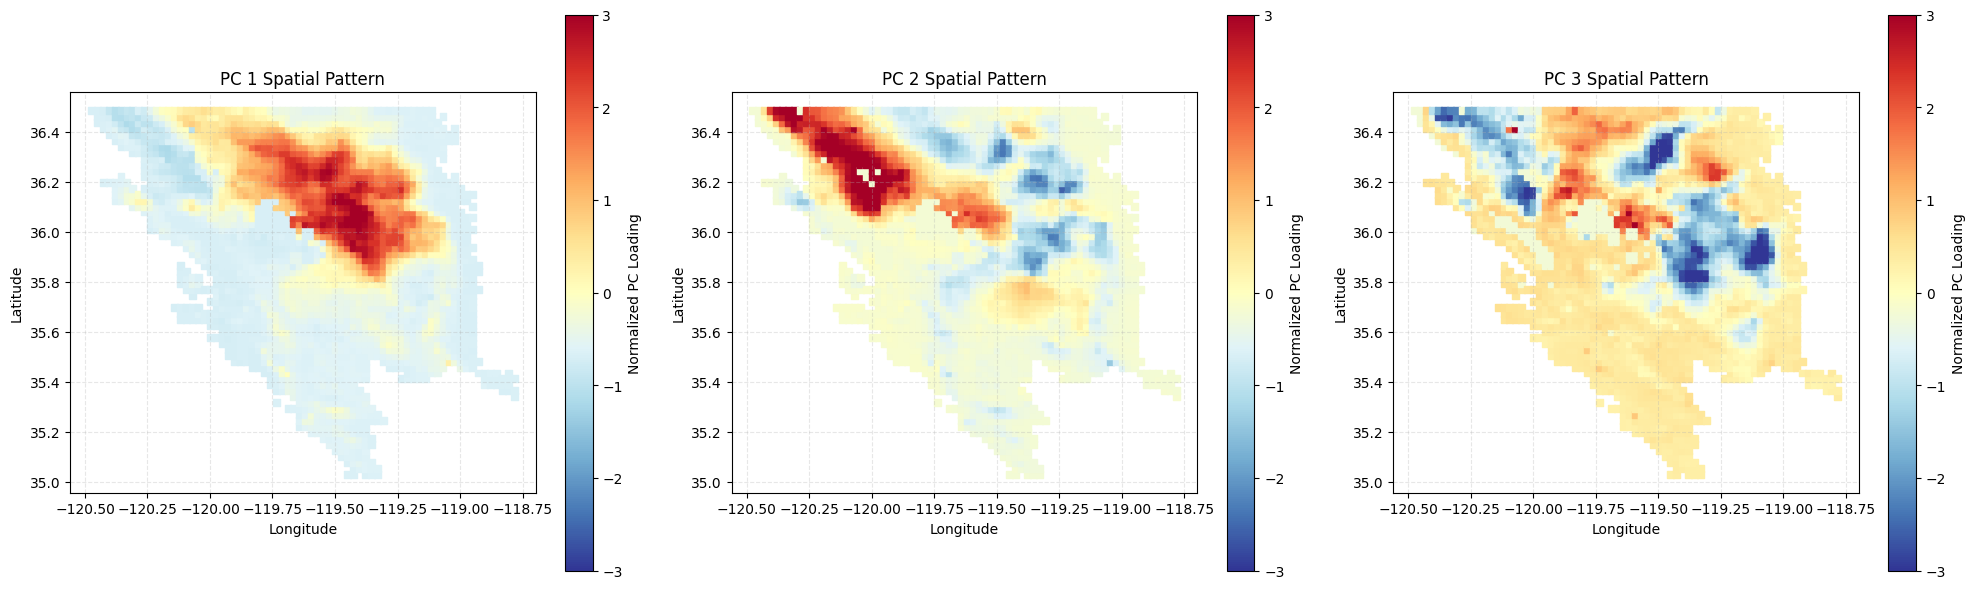

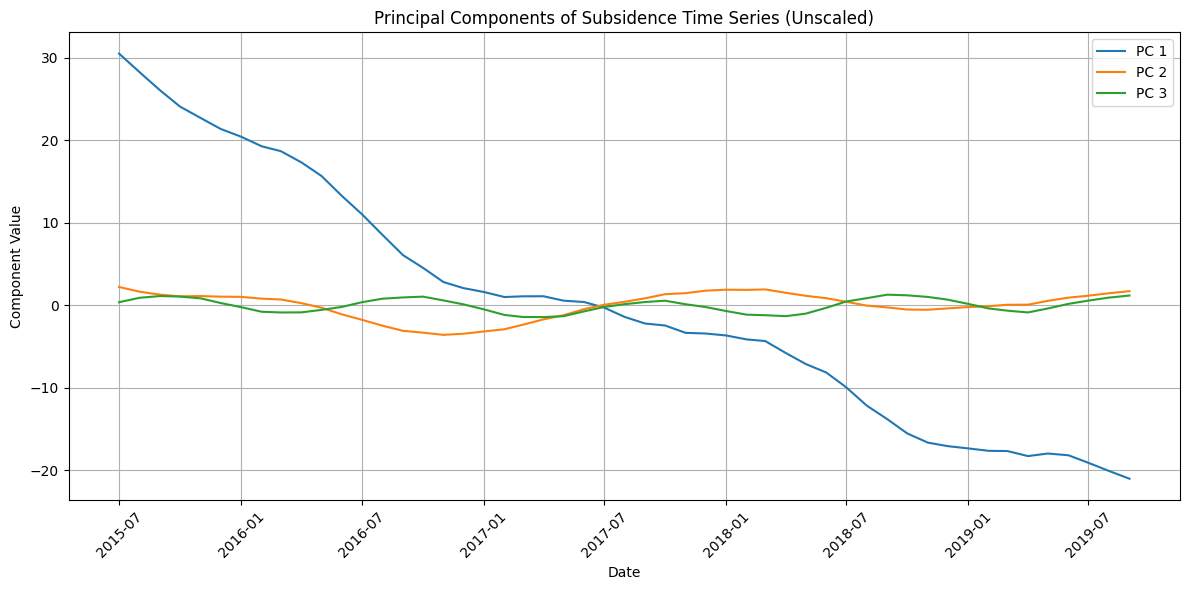

In [ ]:
"""
Performs Principal Component Analysis (PCA) on subsidence data to extract dominant spatial and temporal patterns.
1. Loads and preprocesses data, handling missing values.
2. Runs PCA on unscaled data to identify principal components.
3. Visualizes spatial distributions and temporal variations of extracted components.
"""

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Truncate data to Feb 2020
df = df[df['Date'] <= '2019-09-01']

# Create pivot table
pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')
pivot_df = pivot_df.interpolate(method='linear', axis=0)
pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
pivot_df = pivot_df.fillna(pivot_df.mean())

# Get coordinates
coords = np.array([[x, y] for x, y in zip(
    pivot_df.columns.get_level_values(0),
    pivot_df.columns.get_level_values(1)
)])

# Run PCA on unscaled data
pca = PCA(n_components=3, random_state=42)
components = pca.fit_transform(pivot_df)

# Normalize loading patterns
normalized_loading = (pca.components_.T - pca.components_.T.mean(axis=0)) / pca.components_.T.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i in range(3):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_loading[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'PC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized PC Loading')
plt.tight_layout()
plt.show()

# Plot raw time series
fig, ax = plt.subplots(figsize=(12, 6))
dates = pivot_df.index

# Plot components without scaling
for i in range(3):
    ax.plot(dates, components[:, i], label=f'PC {i+1}')
ax.set_xlabel('Date')
ax.set_ylabel('Component Value')
ax.set_title('Principal Components of Subsidence Time Series (Unscaled)')
ax.grid(True)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


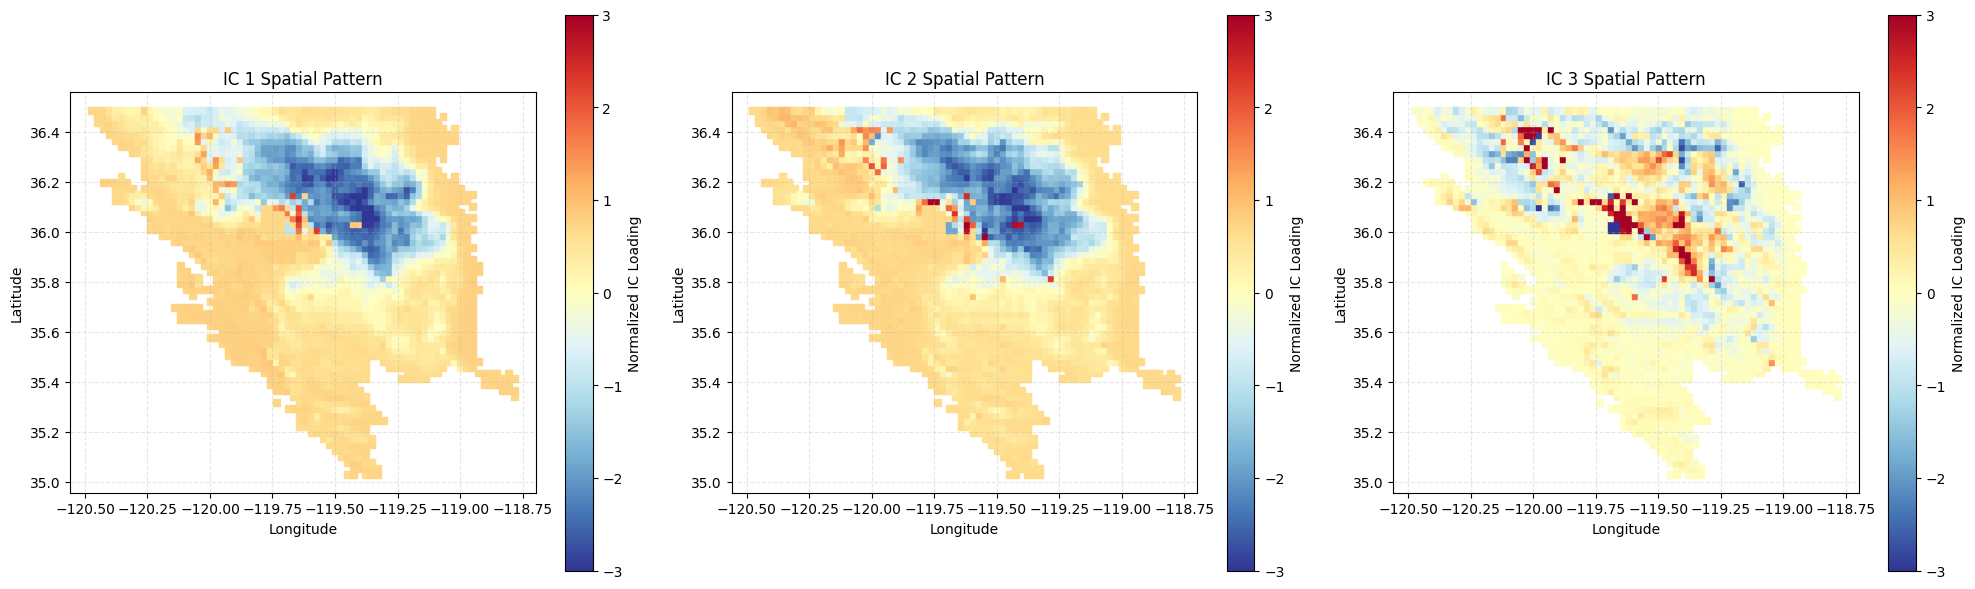

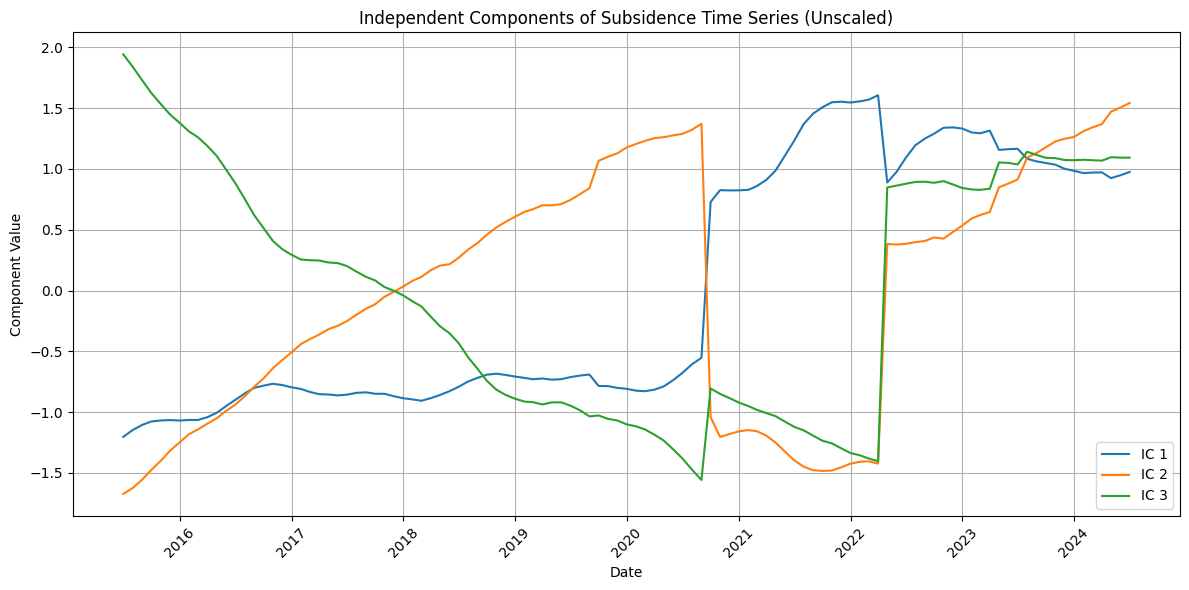

In [ ]:
"""
Applies Independent Component Analysis (ICA) to subsidence data to extract independent spatial and temporal patterns.
1. Loads and preprocesses data, handling missing values.
2. Runs ICA on unscaled data to separate independent subsidence signals.
3. Visualizes extracted spatial distributions and temporal variations.
"""

import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Create pivot table
pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')
pivot_df = pivot_df.interpolate(method='linear', axis=0)
pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
pivot_df = pivot_df.fillna(pivot_df.mean())

# Get coordinates
coords = np.array([[x, y] for x, y in zip(
    pivot_df.columns.get_level_values(0),
    pivot_df.columns.get_level_values(1)
)])

# Run ICA on unscaled data
ica = FastICA(n_components=3, random_state=42)
components = ica.fit_transform(pivot_df)

# Normalize mixing coefficients
normalized_mixing = (ica.mixing_ - ica.mixing_.mean(axis=0)) / ica.mixing_.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i in range(3):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_mixing[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'IC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized IC Loading')
plt.tight_layout()
plt.show()

# Plot raw time series
fig, ax = plt.subplots(figsize=(12, 6))
dates = pivot_df.index

# Plot components without scaling
for i in range(3):
    ax.plot(dates, components[:, i], label=f'IC {i+1}')
ax.set_xlabel('Date')
ax.set_ylabel('Component Value')
ax.set_title('Independent Components of Subsidence Time Series (Unscaled)')
ax.grid(True)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


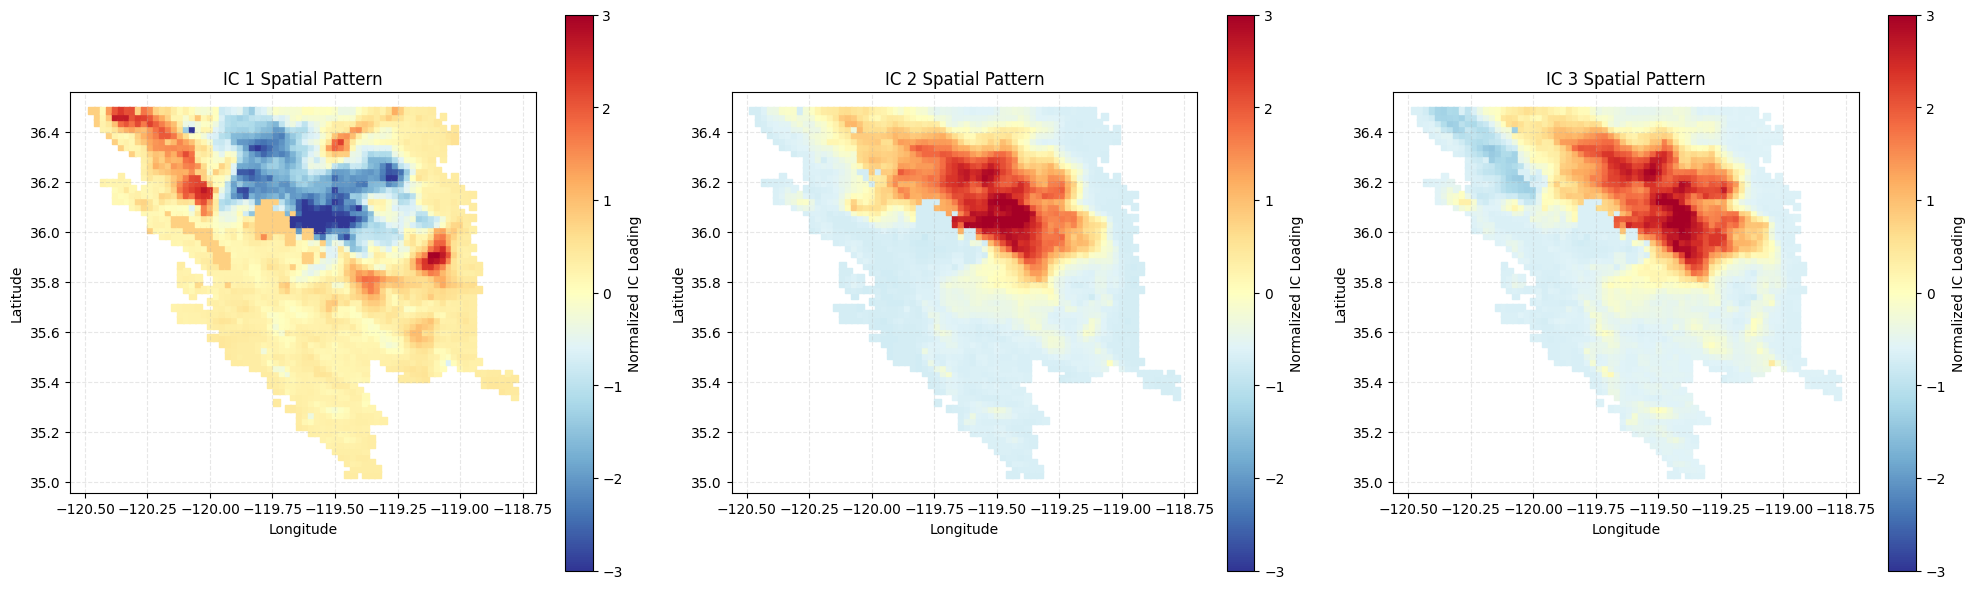

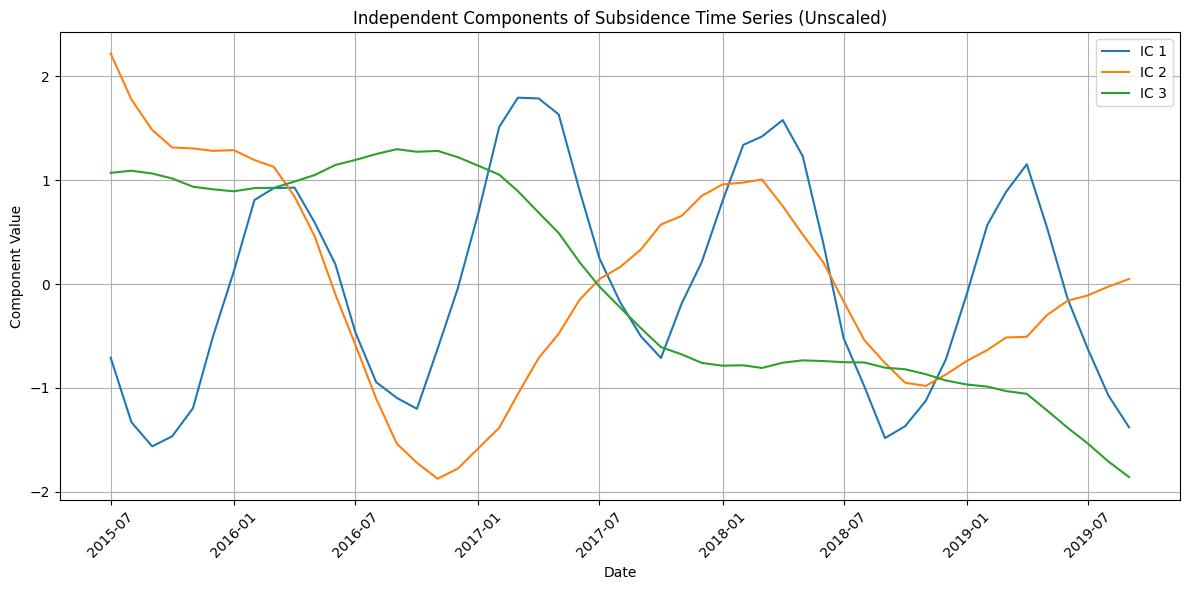

In [ ]:
"""
Applies Independent Component Analysis (ICA) to subsidence data to extract independent spatial and temporal patterns.
1. Loads and preprocesses data, handling missing values.
2. Runs ICA on unscaled data to separate independent subsidence signals.
3. Visualizes spatial patterns and temporal variations of extracted components.
"""

import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Truncate data to May 2020
df = df[df['Date'] <= '2019-09-01']

# Create pivot table
pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')
pivot_df = pivot_df.interpolate(method='linear', axis=0)
pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
pivot_df = pivot_df.fillna(pivot_df.mean())

# Get coordinates
coords = np.array([[x, y] for x, y in zip(
    pivot_df.columns.get_level_values(0),
    pivot_df.columns.get_level_values(1)
)])

# Run ICA on unscaled data
ica = FastICA(n_components=3, random_state=42)
components = ica.fit_transform(pivot_df)

# Normalize mixing coefficients
normalized_mixing = (ica.mixing_ - ica.mixing_.mean(axis=0)) / ica.mixing_.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i in range(3):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_mixing[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'IC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized IC Loading')
plt.tight_layout()
plt.show()

# Plot raw time series
fig, ax = plt.subplots(figsize=(12, 6))
dates = pivot_df.index

# Plot components without scaling
for i in range(3):
    ax.plot(dates, components[:, i], label=f'IC {i+1}')
ax.set_xlabel('Date')
ax.set_ylabel('Component Value')
ax.set_title('Independent Components of Subsidence Time Series (Unscaled)')
ax.grid(True)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


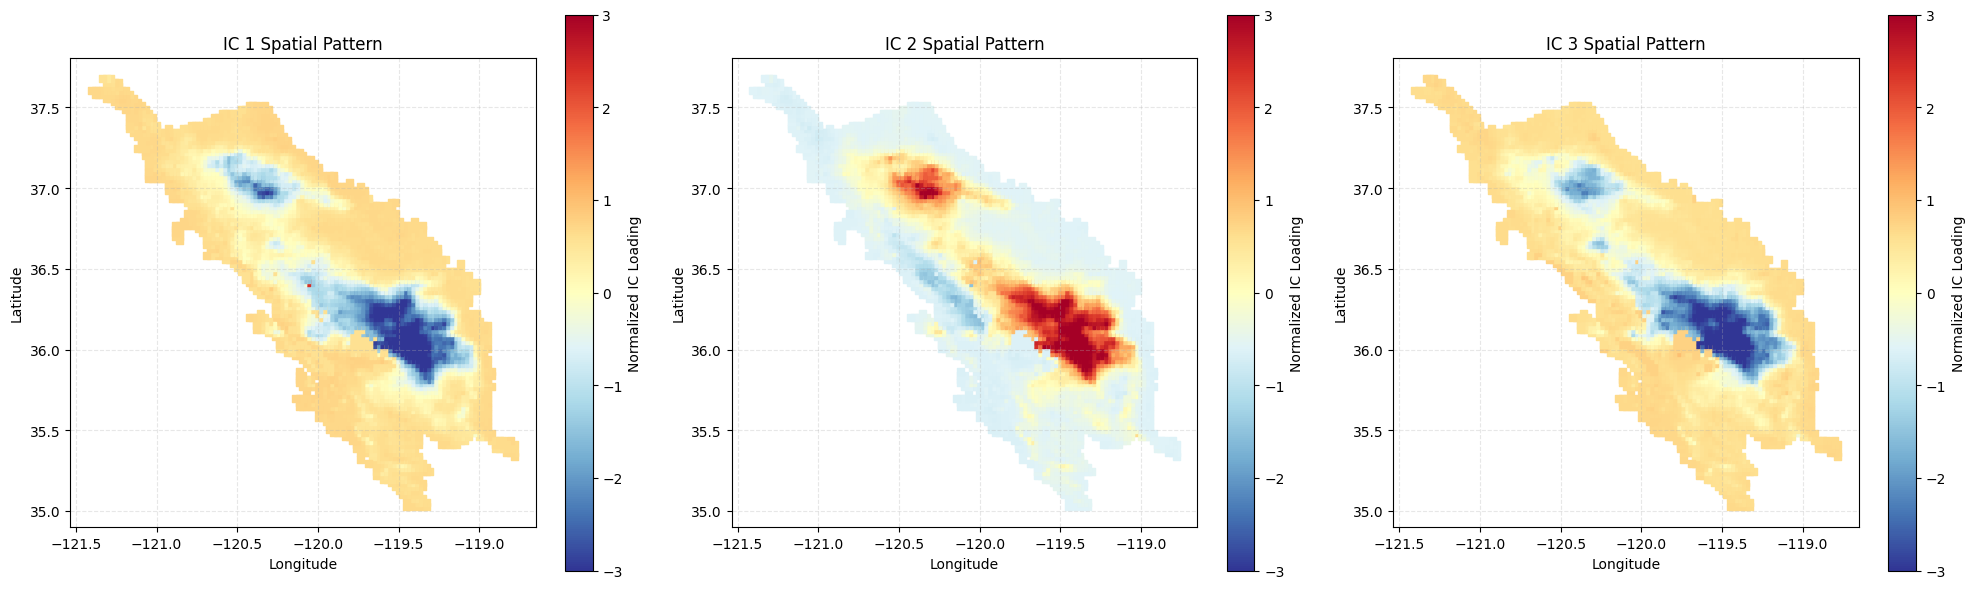

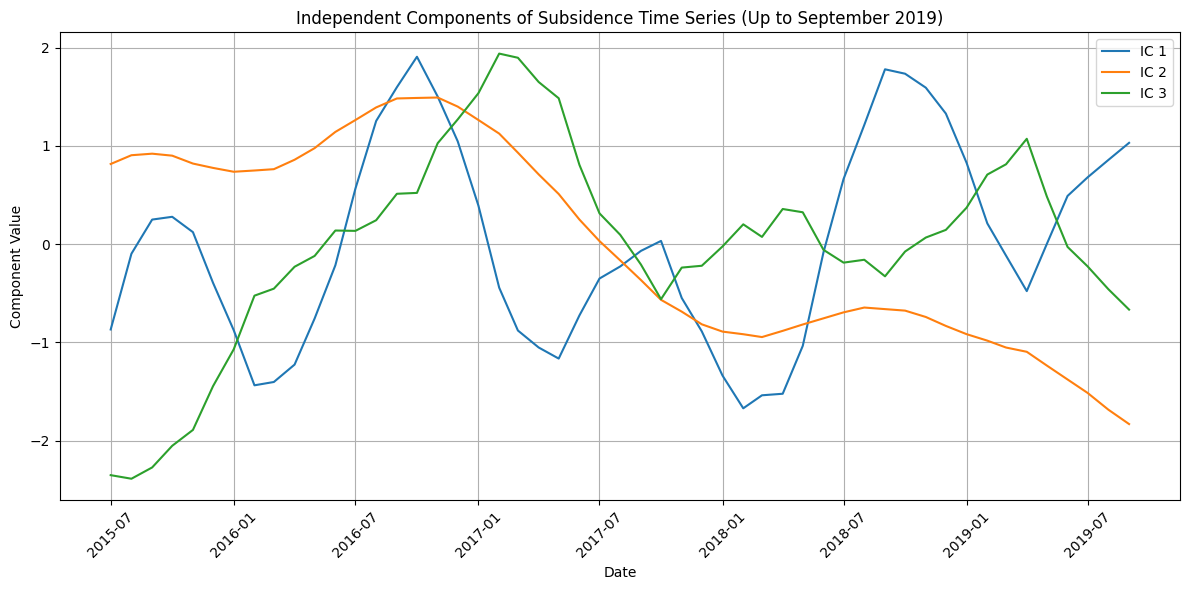

In [ ]:

"""
Applies Independent Component Analysis (ICA) to subsidence data to extract spatial and temporal patterns.
1. Loads and preprocesses data, truncating it to September 2019.
2. Converts column names to spatial coordinates.
3. Runs ICA on unscaled data to separate independent subsidence signals.
4. Visualizes spatial patterns and temporal variations of extracted components.
"""

import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_2019.csv', index_col='Date')
df.index = pd.to_datetime(df.index)

# Truncate data to September 2019
df = df[df.index <= '2019-09-30']

# Prepare data matrix and coordinates
X = df.values
coords = np.array([list(map(float, col.split('_'))) for col in df.columns])

# Run ICA on unscaled data
ica = FastICA(n_components=3, random_state=42)
components = ica.fit_transform(X)

# Normalize mixing coefficients
normalized_mixing = (ica.mixing_ - ica.mixing_.mean(axis=0)) / ica.mixing_.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i in range(3):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_mixing[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'IC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized IC Loading')
plt.tight_layout()
plt.show()

# Plot raw time series
fig, ax = plt.subplots(figsize=(12, 6))
dates = df.index
for i in range(3):
    ax.plot(dates, components[:, i], label=f'IC {i+1}')
ax.set_xlabel('Date')
ax.set_ylabel('Component Value')
ax.set_title('Independent Components of Subsidence Time Series (Up to September 2019)')
ax.grid(True)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


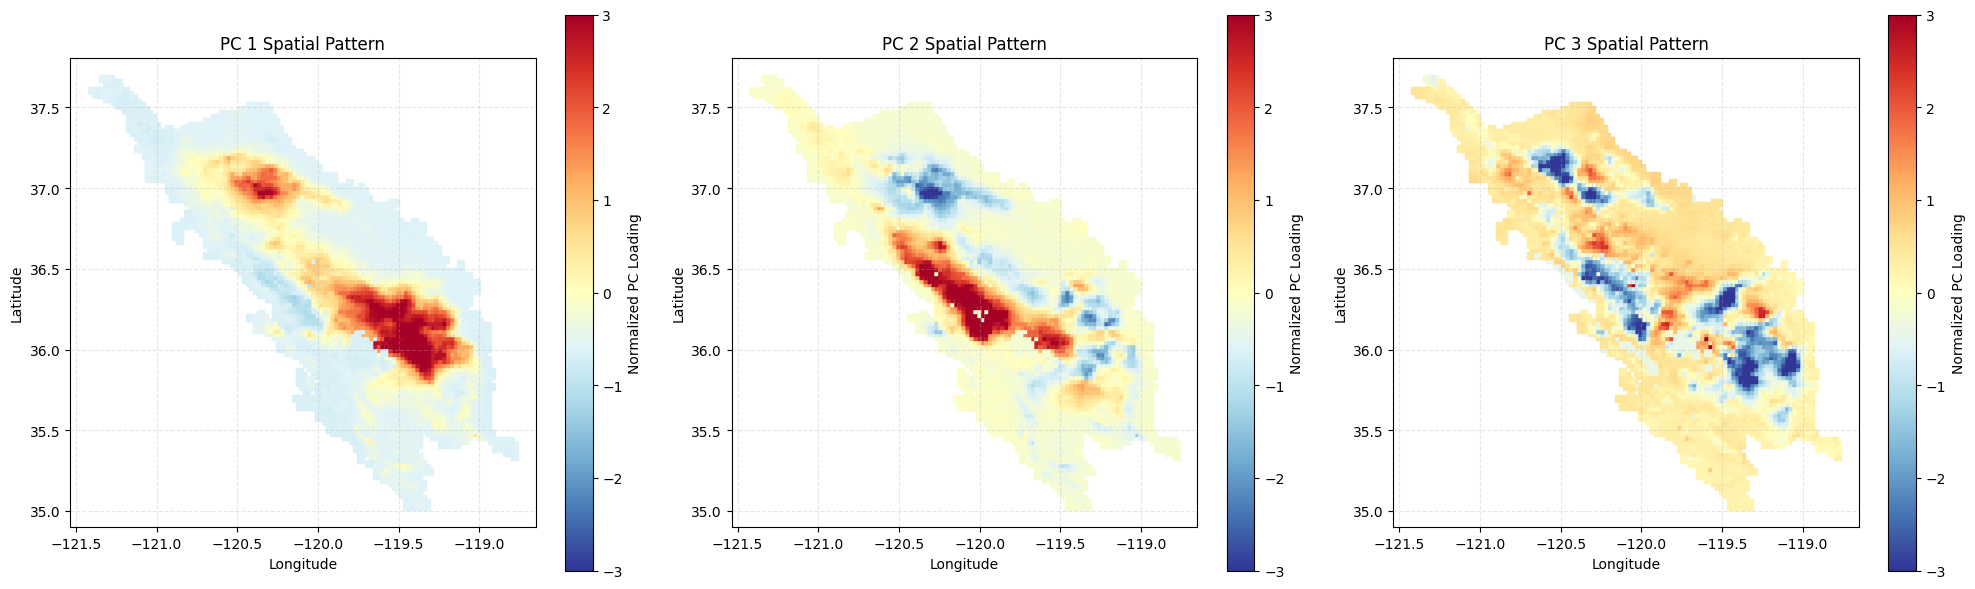

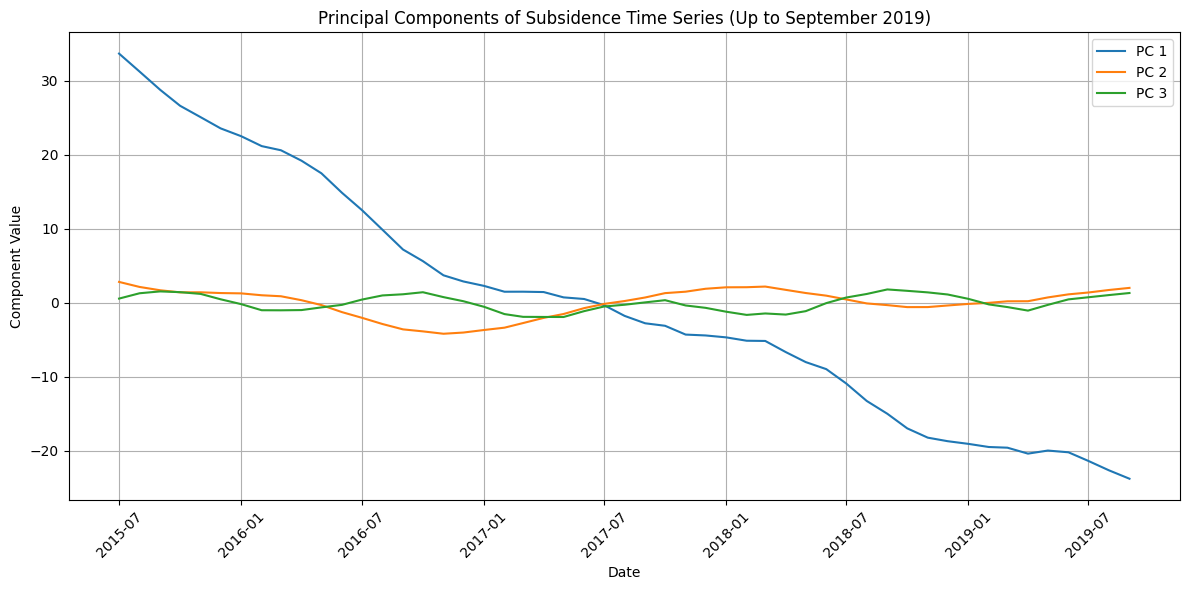

In [ ]:
"""
Performs Principal Component Analysis (PCA) on subsidence data to extract spatial and temporal patterns.
1. Loads and preprocesses data, truncating it to September 2019.
2. Converts column names to spatial coordinates.
3. Runs PCA on unscaled data to identify principal components.
4. Visualizes spatial distributions and temporal variations of extracted components.
"""

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_2019.csv', index_col='Date')
df.index = pd.to_datetime(df.index)

# Truncate data to September 2019
df = df[df.index <= '2019-09-30']

# Prepare data matrix and coordinates
X = df.values
coords = np.array([list(map(float, col.split('_'))) for col in df.columns])

# Run PCA on unscaled data
pca = PCA(n_components=3, random_state=42)
components_pca = pca.fit_transform(X)

# Normalize loading coefficients for PCA
normalized_loading_pca = (pca.components_.T - pca.components_.T.mean(axis=0)) / pca.components_.T.std(axis=0)

# Plot PCA spatial patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i in range(3):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_loading_pca[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'PC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized PC Loading')
plt.tight_layout()
plt.show()

# Plot PCA raw time series
fig, ax = plt.subplots(figsize=(12, 6))
dates = df.index
for i in range(3):
    ax.plot(dates, components_pca[:, i], label=f'PC {i+1}')
ax.set_xlabel('Date')
ax.set_ylabel('Component Value')
ax.set_title('Principal Components of Subsidence Time Series (Up to September 2019)')
ax.grid(True)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


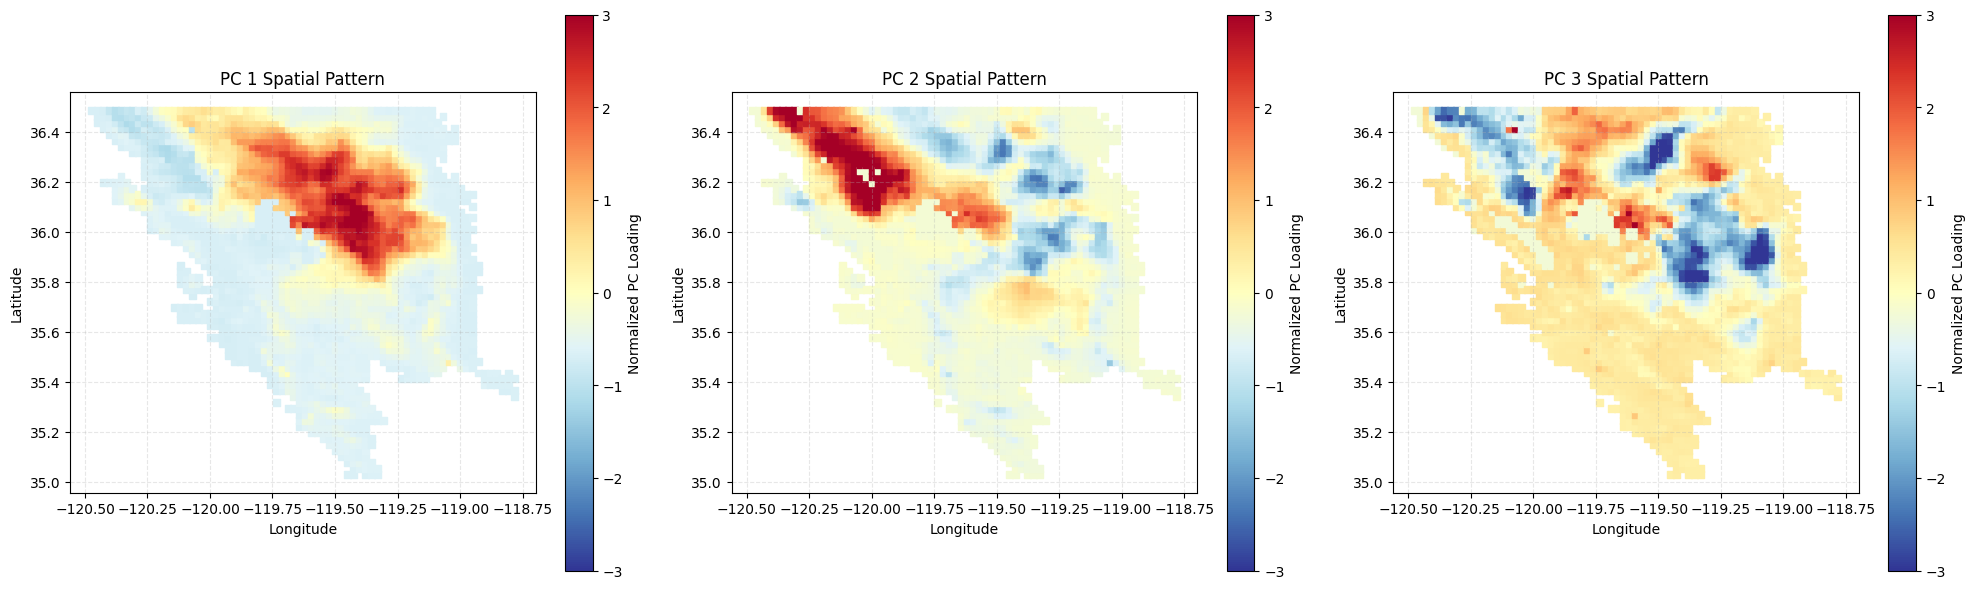

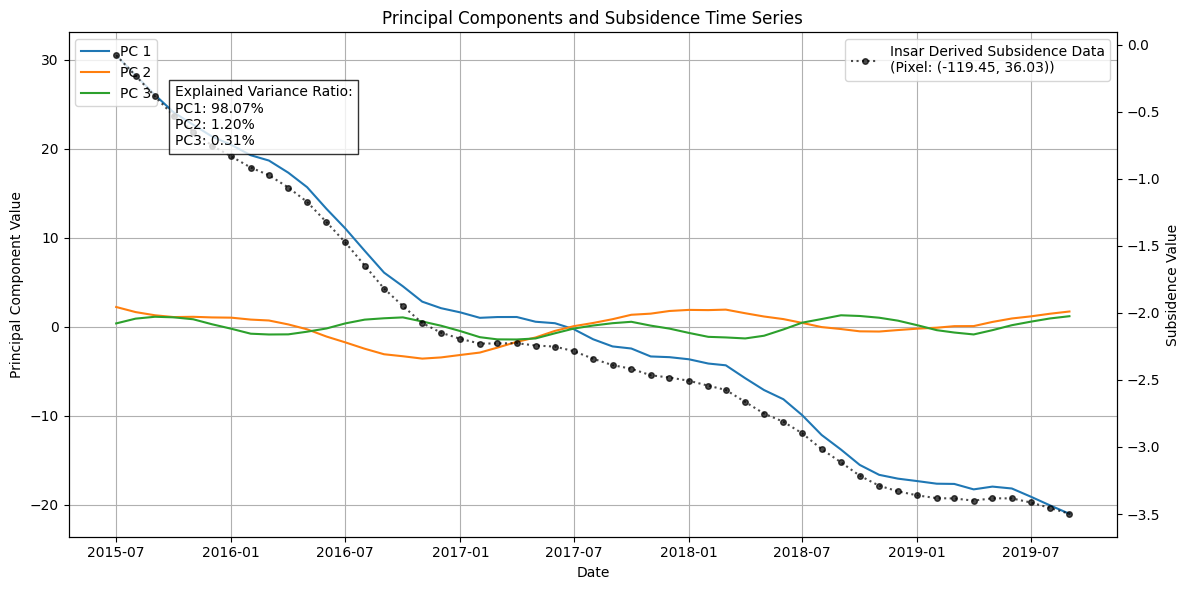

In [ ]:
"""
Performs Principal Component Analysis (PCA) on subsidence data to identify dominant spatial and temporal patterns.
1. Loads and preprocesses data, truncating it to September 2019.
2. Constructs a pivot table, interpolates missing values, and extracts spatial coordinates.
3. Runs PCA on unscaled data and computes the explained variance ratio.
4. Visualizes the spatial distribution of principal components.
5. Identifies the pixel with the least subsidence and plots its time series.
6. Displays PCA time series alongside subsidence data, with a secondary y-axis.
"""

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Truncate data to Feb 2020
df = df[df['Date'] <= '2019-09-01']

# Create pivot table
pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')
pivot_df = pivot_df.interpolate(method='linear', axis=0)
pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
pivot_df = pivot_df.fillna(pivot_df.mean())

# Get coordinates
coords = np.array([[x, y] for x, y in zip(
    pivot_df.columns.get_level_values(0),
    pivot_df.columns.get_level_values(1)
)])

# Run PCA on unscaled data
pca = PCA(n_components=3, random_state=42)
components = pca.fit_transform(pivot_df)
explained_variance_ratio = pca.explained_variance_ratio_

# Normalize loading patterns
normalized_loading = (pca.components_.T - pca.components_.T.mean(axis=0)) / pca.components_.T.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i in range(3):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                               c=normalized_loading[:, i],
                               cmap='RdYlBu_r',
                               s=25,
                               marker='s',
                               vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'PC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized PC Loading')
plt.tight_layout()
plt.show()

# Find least subsidence column and its pixel location
least_subsidence_column = pivot_df.mean(axis=0).idxmin()
# Convert numpy float values to regular Python floats and format as rounded tuple
least_subsidence_coords = (float(least_subsidence_column[0]), float(least_subsidence_column[1]))
least_subsidence_coords = tuple(round(x, 2) for x in least_subsidence_coords)

# Plot raw time series
fig, ax1 = plt.subplots(figsize=(12, 6))
dates = pivot_df.index
least_subsidence_series = pivot_df[least_subsidence_column]

# Plot PCA components
for i in range(3):
    ax1.plot(dates, components[:, i], label=f'PC {i+1}')
ax1.set_xlabel('Date')
ax1.set_ylabel('Principal Component Value')
ax1.set_title('Principal Components and Subsidence Time Series')
ax1.grid(True)
ax1.legend(loc='upper left')

# Add secondary y-axis for subsidence with dotted line and markers
ax2 = ax1.twinx()
ax2.plot(dates, least_subsidence_series, color='black',
         label=f'Insar Derived Subsidence Data\n(Pixel: {least_subsidence_coords})',
         linestyle=':',
         marker='o',
         markersize=4,
         markerfacecolor='black',
         markeredgecolor='black',
         alpha=0.7)
ax2.set_ylabel('Subsidence Value')
ax2.legend(loc='upper right')

# Add explained variance ratio as text
explained_variance_text = "\n".join([f'PC{i+1}: {ratio:.2%}' for i, ratio in enumerate(explained_variance_ratio)])
plt.gcf().text(0.15, 0.75, f'Explained Variance Ratio:\n{explained_variance_text}', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Extract PC1 component values
pc1_values = components[:, 0]

# Create a DataFrame with Date and PC1 values
pc1_df = pd.DataFrame({
    "Date": dates,  # Ensure 'dates' contains the corresponding time series
    "PC1": pc1_values
})

# Save the PC1 values to a CSV file
pc1_df.to_csv("PC1_Component_Subsidence.csv", index=False)

print("PC1 component values have been saved to 'PC1_Componet3_Subsidence.csv'")


PC1 component values have been saved to 'PC1_Componet3_Subsidence.csv'


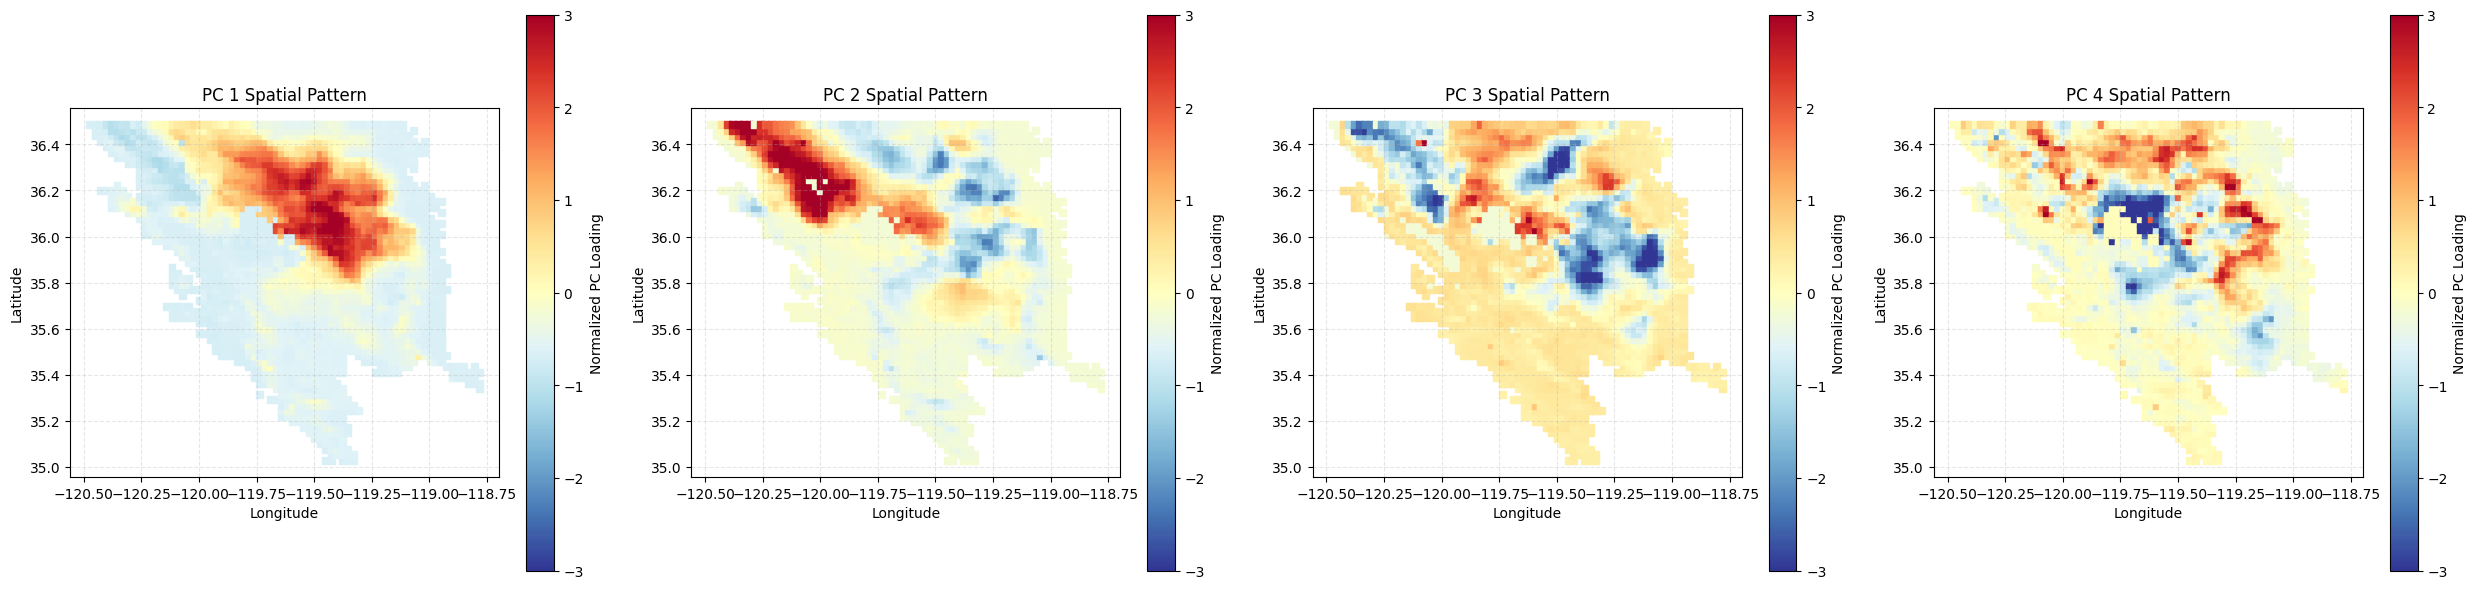

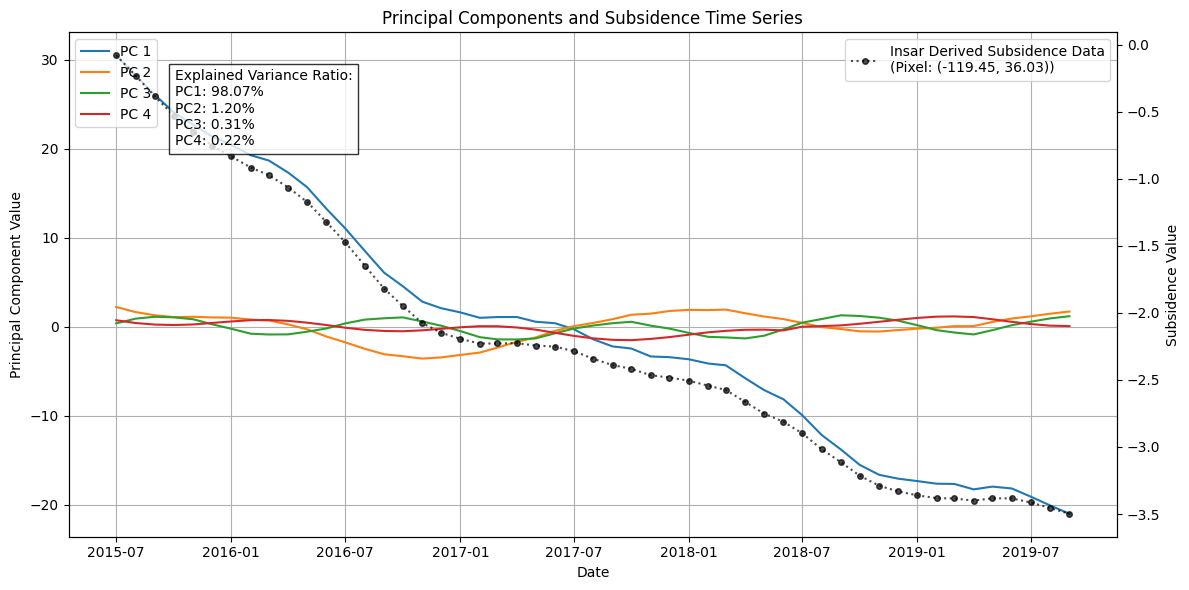

In [ ]:
"""
Performs Principal Component Analysis (PCA) on subsidence data to extract dominant spatial and temporal patterns.
1. Loads and preprocesses data, handling missing values and truncating it to September 2019.
2. Constructs a pivot table, interpolates missing values, and extracts spatial coordinates.
3. Runs PCA on unscaled data with four components and computes the explained variance ratio.
4. Visualizes the spatial distribution of principal components.
5. Identifies the pixel with the least subsidence and plots its time series.
6. Displays PCA time series alongside subsidence data, with a secondary y-axis.
"""

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Truncate data to Feb 2020
df = df[df['Date'] <= '2019-09-01']

# Create pivot table
pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')
pivot_df = pivot_df.interpolate(method='linear', axis=0)
pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
pivot_df = pivot_df.fillna(pivot_df.mean())

# Get coordinates
coords = np.array([[x, y] for x, y in zip(
    pivot_df.columns.get_level_values(0),
    pivot_df.columns.get_level_values(1)
)])

# Run PCA on unscaled data
pca = PCA(n_components=4, random_state=42)
components = pca.fit_transform(pivot_df)
explained_variance_ratio = pca.explained_variance_ratio_

# Normalize loading patterns
normalized_loading = (pca.components_.T - pca.components_.T.mean(axis=0)) / pca.components_.T.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 4, figsize=(25, 6))
for i in range(4):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_loading[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'PC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized PC Loading')
plt.tight_layout()
plt.show()

# Find least subsidence column and its pixel location
least_subsidence_column = pivot_df.mean(axis=0).idxmin()
# Convert numpy float values to regular Python floats and format as rounded tuple
least_subsidence_coords = (float(least_subsidence_column[0]), float(least_subsidence_column[1]))
least_subsidence_coords = tuple(round(x, 2) for x in least_subsidence_coords)

# Plot raw time series
fig, ax1 = plt.subplots(figsize=(12, 6))
dates = pivot_df.index
least_subsidence_series = pivot_df[least_subsidence_column]

# Plot PCA components
for i in range(4):
    ax1.plot(dates, components[:, i], label=f'PC {i+1}')
ax1.set_xlabel('Date')
ax1.set_ylabel('Principal Component Value')
ax1.set_title('Principal Components and Subsidence Time Series')
ax1.grid(True)
ax1.legend(loc='upper left')

# Add secondary y-axis for subsidence with dotted line and markers
ax2 = ax1.twinx()
ax2.plot(dates, least_subsidence_series, color='black',
         label=f'Insar Derived Subsidence Data\n(Pixel: {least_subsidence_coords})',
         linestyle=':',
         marker='o',
         markersize=4,
         markerfacecolor='black',
         markeredgecolor='black',
         alpha=0.7)
ax2.set_ylabel('Subsidence Value')
ax2.legend(loc='upper right')

# Add explained variance ratio as text
explained_variance_text = "\n".join([f'PC{i+1}: {ratio:.2%}' for i, ratio in enumerate(explained_variance_ratio)])
plt.gcf().text(0.15, 0.75, f'Explained Variance Ratio:\n{explained_variance_text}',
               fontsize=10,
               bbox=dict(facecolor='white', alpha=0.8))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

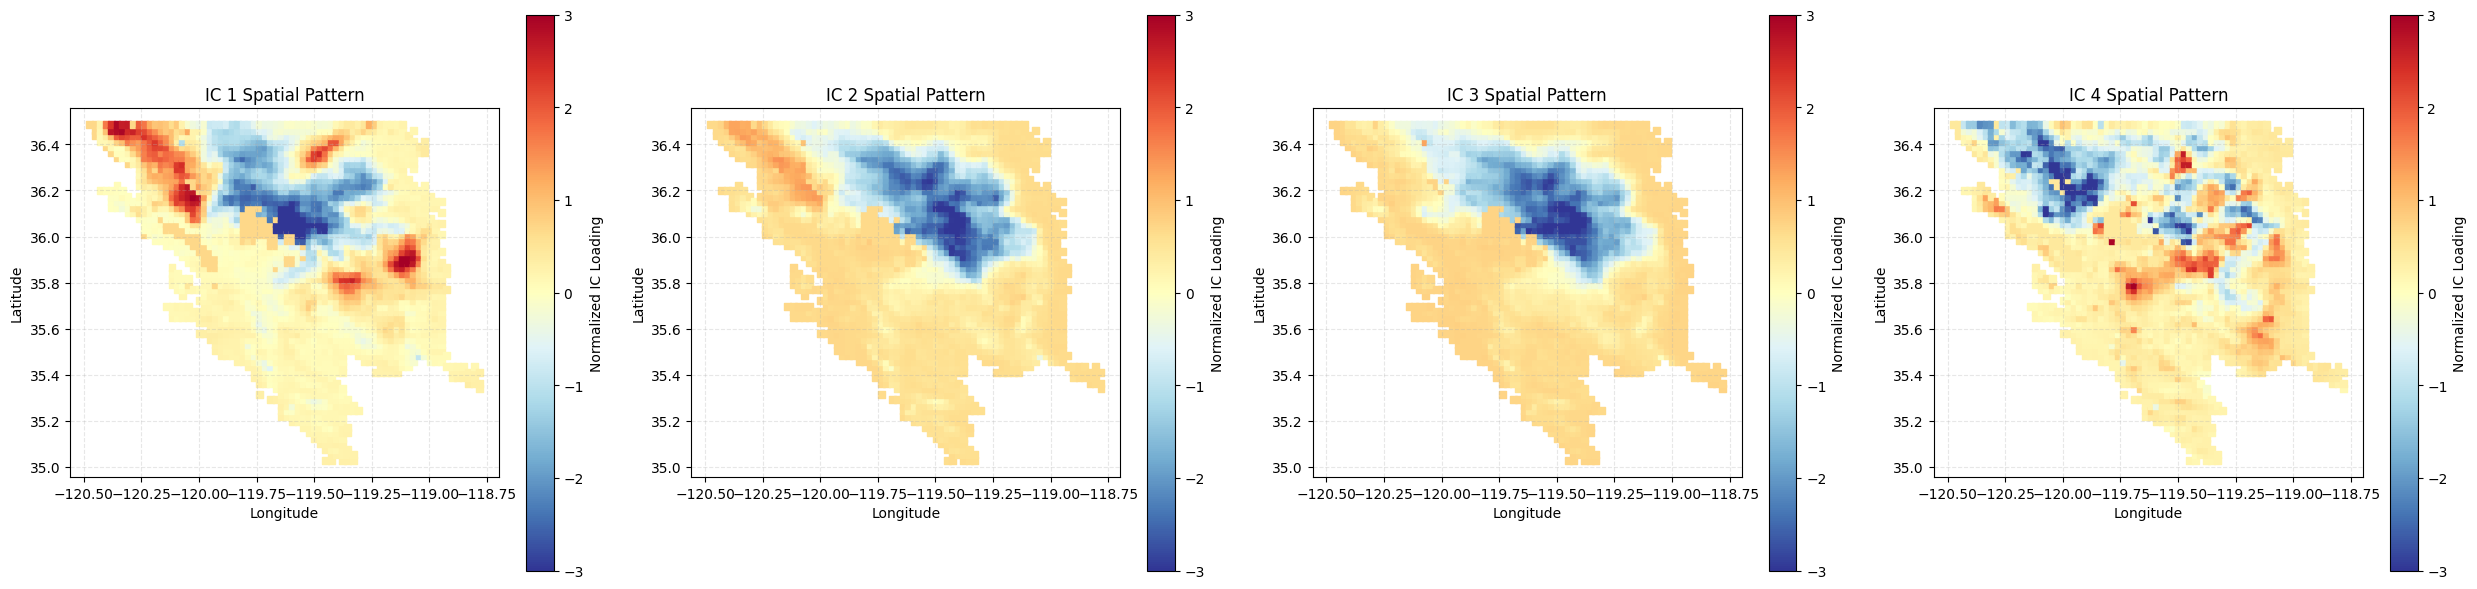

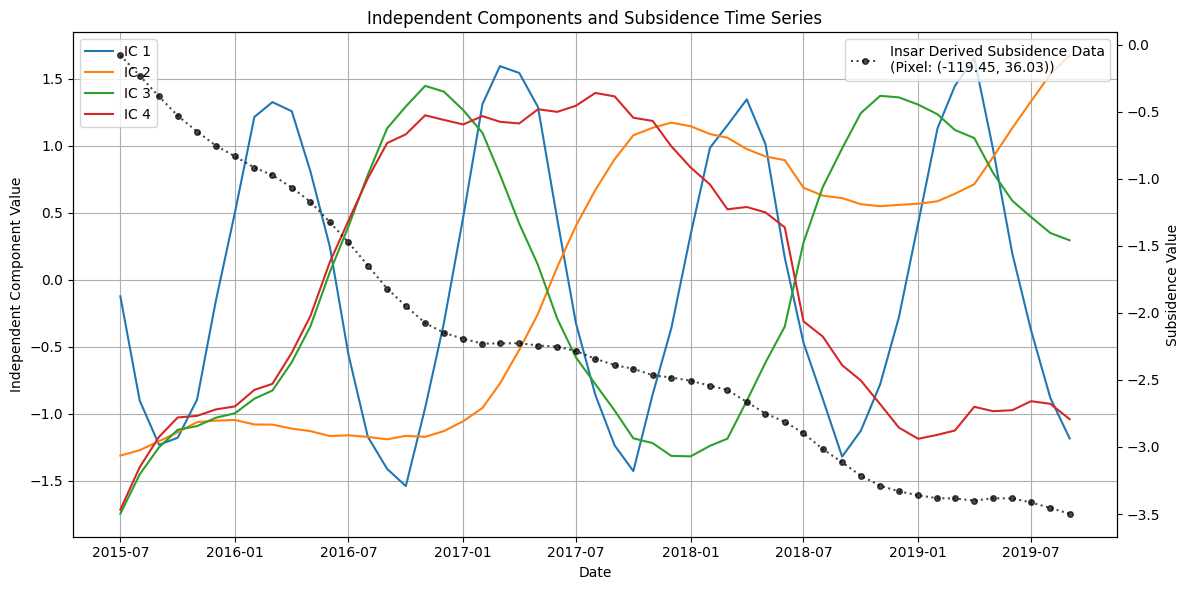

In [ ]:
"""
Performs Independent Component Analysis (ICA) on subsidence data to extract independent spatial and temporal patterns.
1. Loads and preprocesses data, handling missing values and truncating it to September 2019.
2. Constructs a pivot table, interpolates missing values, and extracts spatial coordinates.
3. Runs ICA on unscaled data with four components.
4. Visualizes the spatial distribution of independent components.
5. Identifies the pixel with the least subsidence and plots its time series.
6. Displays ICA time series alongside subsidence data, with a secondary y-axis.
"""

import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Truncate data to Feb 2020
df = df[df['Date'] <= '2019-09-01']

# Create pivot table
pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')
pivot_df = pivot_df.interpolate(method='linear', axis=0)
pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
pivot_df = pivot_df.fillna(pivot_df.mean())

# Get coordinates
coords = np.array([[x, y] for x, y in zip(
    pivot_df.columns.get_level_values(0),
    pivot_df.columns.get_level_values(1)
)])

# Run ICA on unscaled data
ica = FastICA(n_components=4, random_state=42)
components = ica.fit_transform(pivot_df)

# Normalize mixing coefficients
normalized_mixing = (ica.mixing_ - ica.mixing_.mean(axis=0)) / ica.mixing_.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 4, figsize=(25, 6))
for i in range(4):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_mixing[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'IC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized IC Loading')
plt.tight_layout()
plt.show()

# Find least subsidence column and its pixel location
least_subsidence_column = pivot_df.mean(axis=0).idxmin()
# Convert numpy float values to regular Python floats and format as rounded tuple
least_subsidence_coords = (float(least_subsidence_column[0]), float(least_subsidence_column[1]))
least_subsidence_coords = tuple(round(x, 2) for x in least_subsidence_coords)

# Plot raw time series with secondary y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))
dates = pivot_df.index

# Plot components without scaling
for i in range(4):
    ax1.plot(dates, components[:, i], label=f'IC {i+1}')
ax1.set_xlabel('Date')
ax1.set_ylabel('Independent Component Value')
ax1.set_title('Independent Components and Subsidence Time Series')
ax1.grid(True)
ax1.legend(loc='upper left')

# Add secondary y-axis for subsidence with dotted line and markers
ax2 = ax1.twinx()
least_subsidence_series = pivot_df[least_subsidence_column]
ax2.plot(dates, least_subsidence_series,
         color='black',
         label=f'Insar Derived Subsidence Data\n(Pixel: {least_subsidence_coords})',
         linestyle=':',
         marker='o',
         markersize=4,
         markerfacecolor='black',
         markeredgecolor='black',
         alpha=0.7)
ax2.set_ylabel('Subsidence Value')
ax2.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

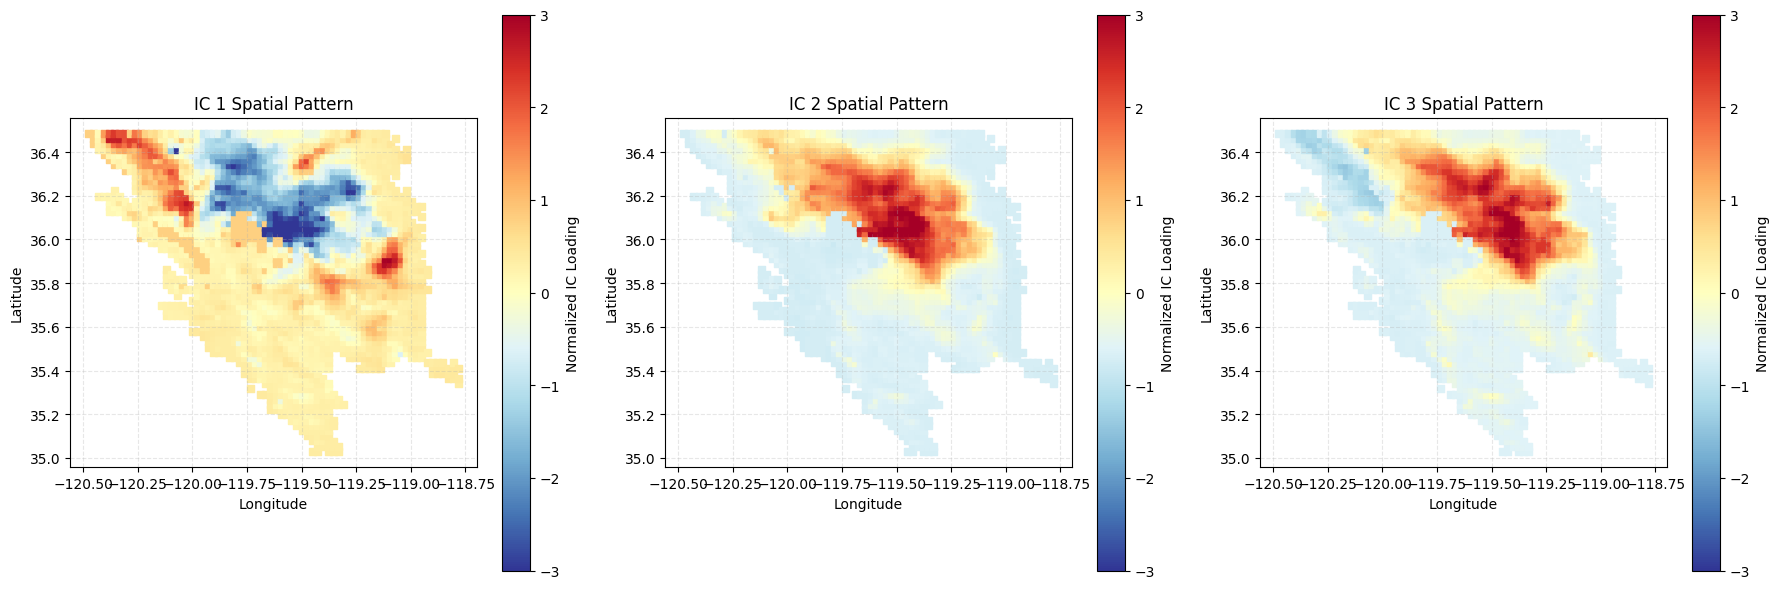

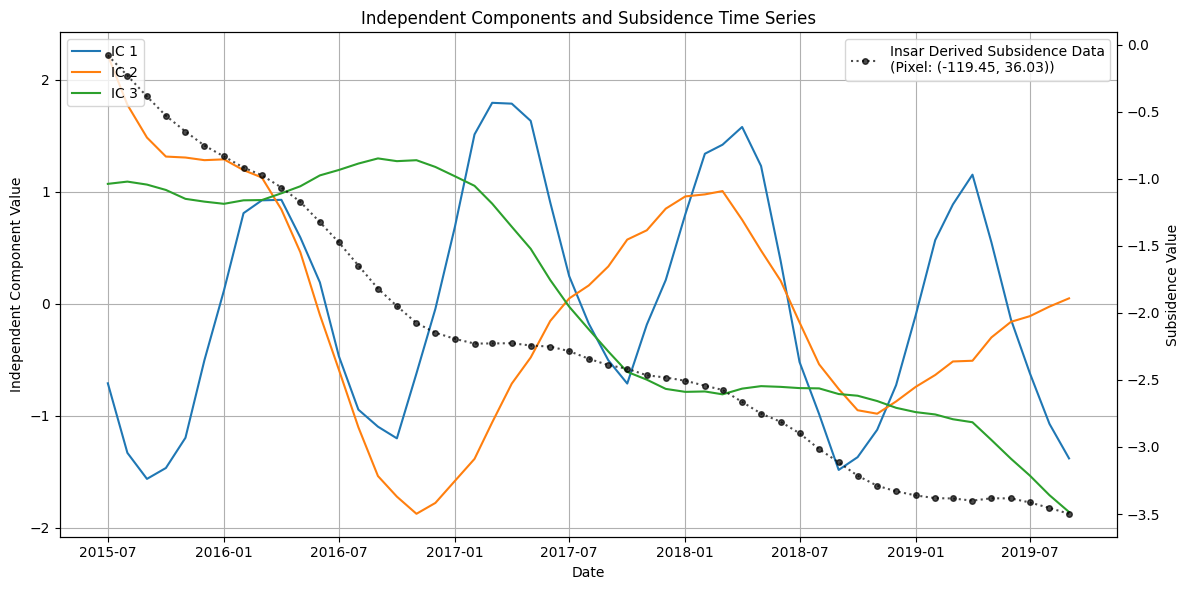

In [ ]:
"""
Applies Independent Component Analysis (ICA) to subsidence data to extract independent spatial and temporal patterns.
1. Loads and preprocesses data, truncating it to September 2019.
2. Constructs a pivot table, interpolates missing values, and extracts spatial coordinates.
3. Runs ICA on unscaled data with three components.
4. Visualizes the spatial distribution of independent components.
5. Identifies the pixel with the least subsidence and plots its time series.
6. Displays ICA time series alongside subsidence data, with a secondary y-axis.
"""

import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('subsidence_data_truncated.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Truncate data to September 2019
df = df[df['Date'] <= '2019-09-01']

# Create pivot table
pivot_df = df.pivot(index='Date', columns=['X', 'Y'], values='Subsidence')
pivot_df = pivot_df.interpolate(method='linear', axis=0)
pivot_df = pivot_df.dropna(axis=1, thresh=int(pivot_df.shape[0] * 0.5))
pivot_df = pivot_df.fillna(pivot_df.mean())

# Get coordinates
coords = np.array([[x, y] for x, y in zip(
    pivot_df.columns.get_level_values(0),
    pivot_df.columns.get_level_values(1)
)])

# Run ICA for 3 components on unscaled data
ica = FastICA(n_components=3, random_state=42)
components = ica.fit_transform(pivot_df)

# Normalize mixing coefficients
normalized_mixing = (ica.mixing_ - ica.mixing_.mean(axis=0)) / ica.mixing_.std(axis=0)

# Plot spatial patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i in range(3):
    scatter = axes[i].scatter(coords[:, 0], coords[:, 1],
                            c=normalized_mixing[:, i],
                            cmap='RdYlBu_r',
                            s=25,
                            marker='s',
                            vmin=-3, vmax=3)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'IC {i+1} Spatial Pattern')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[i], label='Normalized IC Loading')
plt.tight_layout()
plt.show()

# Find least subsidence column and its pixel location
least_subsidence_column = pivot_df.mean(axis=0).idxmin()
# Convert numpy float values to regular Python floats and format as rounded tuple
least_subsidence_coords = (float(least_subsidence_column[0]), float(least_subsidence_column[1]))
least_subsidence_coords = tuple(round(x, 2) for x in least_subsidence_coords)

# Plot raw time series with secondary y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))
dates = pivot_df.index

# Plot components without scaling
for i in range(3):
    ax1.plot(dates, components[:, i], label=f'IC {i+1}')
ax1.set_xlabel('Date')
ax1.set_ylabel('Independent Component Value')
ax1.set_title('Independent Components and Subsidence Time Series')
ax1.grid(True)
ax1.legend(loc='upper left')

# Add secondary y-axis for subsidence with dotted line and markers
ax2 = ax1.twinx()
least_subsidence_series = pivot_df[least_subsidence_column]
ax2.plot(dates, least_subsidence_series,
         color='black',
         label=f'Insar Derived Subsidence Data\n(Pixel: {least_subsidence_coords})',
         linestyle=':',
         marker='o',
         markersize=4,
         markerfacecolor='black',
         markeredgecolor='black',
         alpha=0.7)
ax2.set_ylabel('Subsidence Value')
ax2.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Simulation PC1 range (2010-2015): -264.65 to -181.19
InSAR PC1 range (2015-2019): -21.01 to 30.51


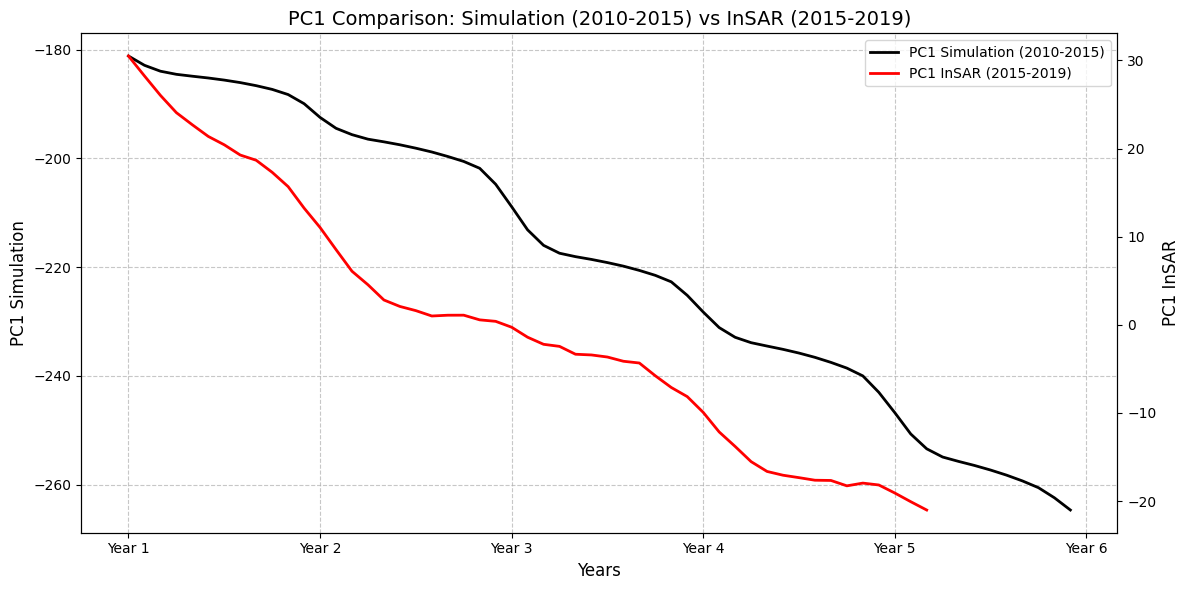

In [ ]:
"""
Compares PC1 component values from simulation (2010-2015) and InSAR data (2015-2019) using a dual-axis plot.
1. Loads and processes data, converting date columns and filtering specific time periods.
2. Assigns sequence numbers for x-axis representation.
3. Plots PC1 values from simulation (black) and InSAR data (red) on separate y-axes.
4. Customizes x-axis labels, grid, and legend for clarity.
5. Displays the range of PC1 values for both datasets.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
df = pd.read_csv('PC1_Component_Valuesfinal.csv')

# Convert all dates to datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Date(insar)'] = pd.to_datetime(df['Date(insar)'])

# Create separate dataframes for simulation and InSAR data
df_sim = df[['Date', 'PC1']].copy()
df_insar = df[['Date(insar)', 'PC1(insar)']].dropna().copy()  # Remove NaN values

# Filter for desired time periods
df_sim_2010_2015 = df_sim[(df_sim['Date'] >= '2010-01-01') & (df_sim['Date'] <= '2015-01-01')].copy()
df_insar_2015_2019 = df_insar[(df_insar['Date(insar)'] >= '2015-01-01') &
                              (df_insar['Date(insar)'] <= '2019-09-01')].copy()

# Create sequence numbers for x-axis
df_sim_2010_2015['Month_Seq'] = range(len(df_sim_2010_2015))
df_insar_2015_2019['Month_Seq'] = range(len(df_insar_2015_2019))

# Create the plot with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Plot simulation data on primary axis
line1 = ax1.plot(df_sim_2010_2015['Month_Seq'], df_sim_2010_2015['PC1'],
                 color='black', linewidth=2, label='PC1 Simulation (2010-2015)')

# Plot InSAR data on secondary axis
line2 = ax2.plot(df_insar_2015_2019['Month_Seq'], df_insar_2015_2019['PC1(insar)'],
                 color='red', linewidth=2, label='PC1 InSAR (2015-2019)')

# Customize the plot
ax1.set_xlabel('Years', fontsize=12)
ax1.set_ylabel('PC1 Simulation', fontsize=12)
ax2.set_ylabel('PC1 InSAR', fontsize=12)

# Create custom x-axis labels
x_ticks = np.linspace(0, max(len(df_sim_2010_2015), len(df_insar_2015_2019)), 6)
x_labels = [f'Year {i+1}' for i in range(6)]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(x_labels)

# Add grid
ax1.grid(True, linestyle='--', alpha=0.7)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# Add title
plt.title('PC1 Comparison: Simulation (2010-2015) vs InSAR (2015-2019)', fontsize=14)

# Print the ranges for reference
print(f"Simulation PC1 range (2010-2015): {df_sim_2010_2015['PC1'].min():.2f} to {df_sim_2010_2015['PC1'].max():.2f}")
print(f"InSAR PC1 range (2015-2019): {df_insar_2015_2019['PC1(insar)'].min():.2f} to {df_insar_2015_2019['PC1(insar)'].max():.2f}")

# Adjust layout and display
plt.tight_layout()
plt.show()